## Scenario 8 — Agentic AI for Circular Multi (global)

- Framework: Multi-agent
- Decision making: **Gemini** (per-tier LLM calls), **strict JSON schema enforced**.
- Agents pick **discrete policy knobs** only: `alpha`, `service_level`, `expedite`.
- All inventory/forecast math remains **deterministic in code**.
- Circular multi chain.


In [ ]:
# ===== G2 — Setup =====
!pip -q install jsonschema google-generativeai

import os, json
from getpass import getpass

# 1) Read API key
if "GEMINI_API_KEY" not in os.environ or not os.environ["GEMINI_API_KEY"]:
    os.environ["GEMINI_API_KEY"] = getpass("Enter GEMINI_API_KEY: ")

# 2) Bypass any local proxies that may force localhost routing
for var in ["HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","http_proxy","https_proxy","all_proxy","no_proxy"]:
    if var in os.environ:
        os.environ.pop(var, None)
# (Optional belt-and-suspenders)
os.environ["NO_PROXY"] = "*"

# 3) Configure client with explicit endpoint
import google.generativeai as genai
genai.configure(
    api_key=os.environ["GEMINI_API_KEY"],
    client_options={"api_endpoint": "https://generativelanguage.googleapis.com"}
)

# 4) Imports
import numpy as np
from dataclasses import dataclass
from typing import Dict, Any, List
from jsonschema import validate, ValidationError

# 5) Test
try:
    mdl = genai.GenerativeModel("gemini-1.5-flash")
    resp = mdl.generate_content("Return the single word: OK", request_options={"timeout": 6})
    print("Smoke test:", (resp.text or "").strip())
except Exception as e:
    print(" Test:", repr(e))

print("Setup complete.")


Enter GEMINI_API_KEY: ··········
Smoke test: OK
Setup complete.


In [ ]:
# ===== R1 — Roles, profiles, project, disruption, InfoBank (MULTI-PROJECT CLOSED LOOP - GLOBAL) =====
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional, Tuple
import numpy as np

rng = np.random.default_rng(42)

demand_df = pd.read_csv("data/project_demand.csv")
waste_df = pd.read_csv("data/project_waste.csv")

SUB_DEMAND_COLUMNS = {"Sub1": "project_1_demand", "Sub2": "project_2_demand", "Sub3": "project_3_demand"}
SUB_WASTE_COLUMNS  = {"Sub1": "project_1_waste",  "Sub2": "project_2_waste",  "Sub3": "project_3_waste"}

def active_length(series):
    nonzero = np.nonzero(series)[0]
    return (nonzero[-1] + 1) if len(nonzero) else len(series)

raw_demand_subs = {sub: demand_df[col].to_numpy() for sub, col in SUB_DEMAND_COLUMNS.items()}
horizonWeeks = min(active_length(arr) for arr in raw_demand_subs.values())

customerDemand_by_sub = {
    sub: arr[:horizonWeeks].astype(float) for sub, arr in raw_demand_subs.items()
}
projectWaste_by_sub = {
    sub: waste_df[col].to_numpy()[:horizonWeeks].astype(float) for sub, col in SUB_WASTE_COLUMNS.items()
}

# Calculate total demand and waste for verification
customerDemand_total = sum(customerDemand_by_sub.values())
projectWaste_total = sum(projectWaste_by_sub.values())

# Ensure all arrays are aligned to the same horizon
for sub in ["Sub1", "Sub2", "Sub3"]:
    assert len(customerDemand_by_sub[sub]) == horizonWeeks, f"{sub} demand has {len(customerDemand_by_sub[sub])} elements, need {horizonWeeks}"
    assert len(projectWaste_by_sub[sub]) == horizonWeeks, f"{sub} waste has {len(projectWaste_by_sub[sub])} elements, need {horizonWeeks}"

# ----------------------------------
# Multi-project closed-loop supply chain structure
# ----------------------------------
SUBS = [f"Sub{i}" for i in range(1, 4)]
POS = [f"PO{i}" for i in range(1, 4)]
THREEPLS = ["3PL_A", "3PL_B"]
DISTS = ["Dist_A", "Dist_B"]
SUPS = ["Sup"]
CLOSED_LOOP = ["CollPoint", "MatRecov"]

ROLES: List[str] = SUBS + POS + THREEPLS + DISTS + SUPS + CLOSED_LOOP

# Helper to pair Sub_i <-> PO_i
def paired_names(role: str) -> Tuple[Optional[str], Optional[str]]:
    if role.startswith("Sub"):
        i = role.replace("Sub", "")
        return role, f"PO{i}"
    if role.startswith("PO"):
        i = role.replace("PO", "")
        return f"Sub{i}", role
    return None, None

# Helper to get branch (A or B)
def dist_branch(role: str) -> Optional[str]:
    if role.startswith("3PL_"):  return role.split("_")[1]
    if role.startswith("Dist_"): return role.split("_")[1]
    return None

# Neighbor map
# - Each Sub_i sees only its PO_i and CollPoint
# - Each PO_i sees Sub_i and both 3PLs (choice will be handled later)
# - 3PL_A sees all POs and Dist_A; 3PL_B sees all POs and Dist_B
# - Dist_A sees 3PL_A and Sup; Dist_B sees 3PL_B and Sup
# - Sup sees both distributors and MatRecov
# - CollPoint sees all Subs and MatRecov
# - MatRecov sees CollPoint and Sup
NEIGHBORS: Dict[str, List[str]] = {}

for i in range(1, 4):
    NEIGHBORS[f"Sub{i}"] = [f"PO{i}", "CollPoint"]
    NEIGHBORS[f"PO{i}"] = [f"Sub{i}", "3PL_A", "3PL_B"]

NEIGHBORS["3PL_A"] = POS + ["Dist_A"]
NEIGHBORS["3PL_B"] = POS + ["Dist_B"]
NEIGHBORS["Dist_A"] = ["3PL_A", "Sup"]
NEIGHBORS["Dist_B"] = ["3PL_B", "Sup"]
NEIGHBORS["Sup"] = ["Dist_A", "Dist_B", "MatRecov"]
NEIGHBORS["CollPoint"] = SUBS + ["MatRecov"]
NEIGHBORS["MatRecov"] = ["CollPoint", "Sup"]

@dataclass
class Profile:
    name: str
    policy_version: int = 0
    share_keys: List[str] = field(default_factory=list)

# Create profiles for all roles
profiles: Dict[str, Profile] = {}

# Forward chain profiles
for s in SUBS:
    profiles[s] = Profile(s, share_keys=["backlog"])
for p in POS:
    profiles[p] = Profile(p, share_keys=["backlog", "pipeline"])

profiles["3PL_A"] = Profile("3PL_A", share_keys=["pipeline"])
profiles["3PL_B"] = Profile("3PL_B", share_keys=["pipeline"])
profiles["Dist_A"] = Profile("Dist_A", share_keys=["on_hand", "backlog"])
profiles["Dist_B"] = Profile("Dist_B", share_keys=["on_hand", "backlog"])
profiles["Sup"] = Profile("Sup", share_keys=["on_hand", "pipeline"])

# Closed-loop profiles
profiles["CollPoint"] = Profile("CollPoint", share_keys=["on_hand"])
profiles["MatRecov"] = Profile("MatRecov", share_keys=["on_hand", "pipeline"])

# Keep only used project info
project = {"id": "P1_Multi", "material": "Rebar#5", "type": "renovation"}

disruption = {"week": 30, "delta_leadtime": 2, "duration_weeks": 8}

# Recovery parameters
RECOVERY_RATE = 0.90  # 90% of waste can be recovered
RECOVERY_LEAD_TIME = 3  # 3 weeks to process waste into usable materials

# Keep only used noise parameter
leadtime_noise = 0.0

def degrade_obs(x: float, rel_std: float, rng) -> float:
    return float(max(0.0, x * (1.0 + rng.normal(0.0, rel_std))))

# Small helpers to interpret role names
def role_type(role: str) -> str:
    if role.startswith("Sub"): return "Sub"
    if role.startswith("PO"):  return "PO"
    if role.startswith("3PL"): return "3PL"
    if role.startswith("Dist"):return "Dist"
    if role == "Sup":          return "Sup"
    if role == "CollPoint":    return "CollPoint"
    if role == "MatRecov":     return "MatRecov"
    return role

class InfoBank:
    def __init__(self, profiles: Dict[str, Profile], rng, info_regime: str = "global"):
        if info_regime not in ["local", "global"]:
            raise ValueError("info_regime must be 'local' or 'global'")
        self.profiles = profiles
        self.rng = rng
        self.info_regime = info_regime
        self.local: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

        # Shared views
        if info_regime == "local":
            # Each receiver keeps neighbors' shared data
            self.shared: Dict[str, Dict[str, Dict[str, Any]]] = {
                role: {neighbor: {} for neighbor in NEIGHBORS.get(role, [])}
                for role in ROLES
            }
        else:
            self.shared: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

        # Lead times (extended for multi-project closed loop)
        self.true_lead: Dict[str, int] = {
            # Forward chain lead times
            "Sup->Dist_A": 3,
            "Sup->Dist_B": 3,
            "Dist_A->3PL_A": 1,
            "Dist_B->3PL_B": 1,
            # both 3PL branches to any PO have the same nominal LT
            "3PL->PO": 1,
            # each PO_i to its Sub_i
            "PO->Sub": 0,
            # Reverse chain lead times
            "Sub->CollPoint": 1,
            "CollPoint->MatRecov": 2,
            "MatRecov->Sup": RECOVERY_LEAD_TIME
        }
        self.time = 0

    def apply_disruption(self, t: int):
        # Same disruption as your base: affects Sup -> Dist only
        if t == disruption["week"]:
            self.true_lead["Sup->Dist_A"] += disruption["delta_leadtime"]
            self.true_lead["Sup->Dist_B"] += disruption["delta_leadtime"]
        if t == disruption["week"] + disruption["duration_weeks"]:
            self.true_lead["Sup->Dist_A"] -= disruption["delta_leadtime"]
            self.true_lead["Sup->Dist_B"] -= disruption["delta_leadtime"]

    def update_share_policy(self, role: str, add_keys: Optional[List[str]] = None, drop_keys: Optional[List[str]] = None):
        p = self.profiles[role]
        if add_keys:
            for k in add_keys:
                if k not in p.share_keys and k in ["on_hand", "backlog", "pipeline"]:
                    p.share_keys.append(k)
        if drop_keys:
            p.share_keys = [k for k in p.share_keys if k not in drop_keys]
        p.policy_version += 1

    def publish(self, role: str):
        """Publish according to information regime"""
        policy_keys = set(self.profiles[role].share_keys)
        shared_data = {k: self.local[role].get(k) for k in policy_keys if k in self.local[role]}

        if self.info_regime == "local":
            for neighbor in NEIGHBORS.get(role, []):
                if neighbor in ROLES:
                    if neighbor not in self.shared:
                        self.shared[neighbor] = {}
                    self.shared[neighbor][role] = shared_data.copy()
        else:
            self.shared[role] = shared_data.copy()

    def context_view_for(self, role: str) -> Dict[str, Any]:
        view = {
            "role": role,
            "t": self.time,
            "project_id": project["id"],
            "material": project["material"],
            "project_type": project["type"]
        }
        view[f"{role}_self"] = {k: self.local[role].get(k) for k in self.local[role].keys()}

        if self.info_regime == "local":
            visible_roles = NEIGHBORS.get(role, [])
            for neighbor_role in visible_roles:
                neighbor_shared_data = self.shared.get(role, {}).get(neighbor_role, {})
                view[f"{neighbor_role}_shared"] = neighbor_shared_data
        else:
            visible_roles = [r for r in ROLES if r != role]
            for r in visible_roles:
                view[f"{r}_shared"] = self.shared.get(r, {}).copy()

        view["my_profile"] = {"policy_version": self.profiles[role].policy_version}
        view["info_regime_context"] = {
            "regime": self.info_regime,
            "visible_roles": visible_roles,
            "total_network_size": len(ROLES)
        }
        return view

    def _get_shared_insights(self, role: str) -> Dict[str, float]:
        """Aggregate coarse insights from shared data."""
        downstream_backlog = 0.0
        upstream_inventory = 0.0
        visible_partners = []

        # Extended chain order for multi-project closed loop
        chain_order = {"Sup": 0, "Dist_A": 1, "Dist_B": 1, "3PL_A": 2, "3PL_B": 2,
                       "PO": 3, "Sub": 4, "CollPoint": 5, "MatRecov": 6}
        rt = role_type(role)
        my_position = chain_order.get(rt, 3)

        if self.info_regime == "local":
            neighbors = NEIGHBORS.get(role, [])
            for neighbor_role in neighbors:
                shared_data = self.shared.get(role, {}).get(neighbor_role, {})
                if shared_data:
                    visible_partners.append(neighbor_role)
                    nr_type = role_type(neighbor_role)
                    partner_position = chain_order.get(nr_type, 3)

                    if partner_position > my_position and "backlog" in shared_data:
                        downstream_backlog += float(shared_data["backlog"])
                    if partner_position < my_position and "on_hand" in shared_data:
                        upstream_inventory += float(shared_data["on_hand"])
        else:
            # Global regime: no distance weighting - equal access to all roles
            visible_roles = [r for r in ROLES if r != role]
            for visible_role in visible_roles:
                shared_data = self.shared.get(visible_role, {})
                if not shared_data:
                    continue
                visible_partners.append(visible_role)

                vr_type = role_type(visible_role)
                partner_position = chain_order.get(vr_type, 3)

                if partner_position > my_position and "backlog" in shared_data:
                    downstream_backlog += float(shared_data["backlog"])
                if partner_position < my_position and "on_hand" in shared_data:
                    upstream_inventory += float(shared_data["on_hand"])

        return {
            "downstream_backlog": downstream_backlog,
            "upstream_inventory": upstream_inventory,
            "visible_partners": len(visible_partners)
        }

    def math_signals_for(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
        t = self.time
        rtype = role_type(role)

        def _safe_get_orders(h, key_role):
            try:
                return np.asarray(h.get("orders_out", {}).get(key_role, []), dtype=float).ravel()
            except Exception:
                return np.asarray([], dtype=float)

        # Determine downstream orders signal by role type
        if rtype == "Sub":
            # Use that sub's own customer demand series
            downstream_orders = np.asarray(customerDemand_by_sub[role], dtype=float)
        elif rtype == "PO":
            # Orders from its paired Sub_i if available; fallback to that sub's demand
            sub_i, _ = paired_names(role)
            if "orders_out" in hist and sub_i in hist.get("orders_out", {}):
                downstream_orders = np.asarray(hist["orders_out"][sub_i], dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_by_sub[sub_i], dtype=float)
        elif rtype == "3PL":
            # Aggregate PO orders (all POs) as downstream demand proxy
            if "orders_out" in hist:
                po_keys = [k for k in hist["orders_out"].keys() if k.startswith("PO")]
                if po_keys:
                    downstream_orders = np.sum([np.asarray(hist["orders_out"][k], dtype=float) for k in po_keys], axis=0)
                else:
                    downstream_orders = np.asarray(customerDemand_total, dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_total, dtype=float)
        elif rtype == "Dist":
            # Use orders from its 3PL branch only
            my_branch = dist_branch(role)
            tpl_key = f"3PL_{my_branch}"
            if "orders_out" in hist and tpl_key in hist["orders_out"]:
                downstream_orders = np.asarray(hist["orders_out"][tpl_key], dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_total, dtype=float)
        elif rtype == "Sup":
            # Use both distributors' orders if present; else a conservative proxy
            if "orders_out" in hist:
                ds = []
                if "Dist_A" in hist["orders_out"]: ds.append(np.asarray(hist["orders_out"]["Dist_A"], dtype=float))
                if "Dist_B" in hist["orders_out"]: ds.append(np.asarray(hist["orders_out"]["Dist_B"], dtype=float))
                if ds:
                    downstream_orders = np.sum(ds, axis=0)
                else:
                    downstream_orders = np.asarray(customerDemand_total, dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_total, dtype=float)
        elif rtype == "CollPoint":
            # CollPoint receives aggregated waste from all Subs
            downstream_orders = np.asarray(projectWaste_total, dtype=float)
        elif rtype == "MatRecov":
            # MatRecov receives from CollPoint
            coll = _safe_get_orders(hist, "CollPoint")
            base = coll if coll.size else np.asarray(projectWaste_total, dtype=float)
            downstream_orders = base * RECOVERY_RATE
        else:  # unknown role
            downstream_orders = np.zeros_like(np.asarray(customerDemand_total, dtype=float))

        # Demand window stats
        win = downstream_orders[max(0, t-window):t+1]
        dmean = float(win.mean()) if win.size else 0.0
        dstd  = float(win.std(ddof=0)) if win.size else 0.0

        # Shared insights
        shared_insights = self._get_shared_insights(role)
        if shared_insights["downstream_backlog"] > 0 and dmean > 0:
            backlog_factor = 1.0 + min(0.2, shared_insights["downstream_backlog"] / dmean)
            dmean *= backlog_factor

        # Perfect visibility of own inventory position
        inv = float(self.local[role].get("on_hand", 0.0))
        bkl = float(self.local[role].get("backlog", 0.0))
        pip = float(self.local[role].get("pipeline", 0.0))
        invpos_obs = inv + pip - bkl

        # Lead time estimate (by link)
        link = None
        if rtype == "PO":   link = "3PL->PO"
        if rtype == "3PL":  link = f"Dist_{dist_branch(role)}->3PL_{dist_branch(role)}"
        if rtype == "Dist": link = f"Sup->Dist_{dist_branch(role)}"
        if rtype == "Sub":  link = "PO->Sub"
        if rtype == "CollPoint": link = "Sub->CollPoint"
        if rtype == "MatRecov": link = "CollPoint->MatRecov"
        if rtype == "Sup": link = "MatRecov->Sup"  # For recovered materials

        if link is None:
            L_obs = 0.0
        else:
            L_true = self.true_lead[link]
            L_obs = degrade_obs(L_true, leadtime_noise, self.rng)

        return {
            "t": t,
            "downstream_mean_obs": dmean,
            "downstream_std_obs": dstd,
            "inventory_position_obs": invpos_obs,
            "lead_time_obs": float(L_obs),
            "shared_visibility": shared_insights["visible_partners"],
            "info_regime": self.info_regime,
            # (optional) pass-through raw insight values if other code expects them
            "upstream_inventory_signal": shared_insights["upstream_inventory"],
            "downstream_backlog_signal": shared_insights["downstream_backlog"],
        }

    def view_for_agent(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
        return {
            "context_view": self.context_view_for(role),
            "math_signals": self.math_signals_for(role, hist, window),
        }

In [ ]:
# ===== R2 — Cleaned LLM Agent Decision Making (MULTI-PROJECT CLOSED LOOP - GLOBAL) =====
import json
from typing import Dict, Any, List
import math
import time
import numpy as np
import google.generativeai as genai

# ----------------------------
# Valid information sharing keys
# ----------------------------
allowed_share_keys = {"on_hand", "backlog", "pipeline"}

# ----------------------------
# Schema-less, deterministic model (matches linear GLOBAL)
# ----------------------------
gemini_coeff_fixed = genai.GenerativeModel(
    model_name="gemini-1.5-flash",
    generation_config=genai.GenerationConfig(
        temperature=0.0,                     # deterministic for research runs
        response_mime_type="application/json"
    ),
    system_instruction=(
        "You are a role-bound decision maker in a multi-agent multi-project closed-loop construction supply chain simulation. "
        "Always output valid JSON with numeric values within the specified ranges. No prose."
    ),
)

REQUIRED_KEYS = {"alpha", "service_level", "lot_multiplier", "expedite", "share_add", "share_drop"}

# ----------------------------
# Validation
# ----------------------------
def validate_coeffs(obj: Dict[str, Any]) -> Dict[str, Any]:
    # Fill optional keys if missing
    obj = {**{"share_add": [], "share_drop": []}, **obj}

    # Enforce exact key set
    keys = set(obj.keys())
    missing = {"alpha","service_level","lot_multiplier","expedite"} - keys
    extras = keys - REQUIRED_KEYS
    if missing:
        raise ValueError(f"Missing required keys: {sorted(missing)}")
    if extras:
        raise ValueError(f"Extra keys not allowed: {sorted(extras)}")

    # Type & domain checks
    if not isinstance(obj["alpha"], (int, float)) or not (0.05 <= float(obj["alpha"]) <= 0.50):
        raise ValueError(f"alpha {obj['alpha']} must be a number in [0.05, 0.50]")
    if not isinstance(obj["service_level"], (int, float)) or not (0.80 <= float(obj["service_level"]) <= 0.95):
        raise ValueError(f"service_level {obj['service_level']} must be a number in [0.80, 0.95]")
    if not isinstance(obj["lot_multiplier"], (int, float)) or not (0.50 <= float(obj["lot_multiplier"]) <= 2.00):
        raise ValueError(f"lot_multiplier {obj['lot_multiplier']} must be a number in [0.50, 2.00]")
    if not isinstance(obj["expedite"], bool):
        raise ValueError(f"expedite {obj['expedite']} must be true or false")

    # Validate sharing keys
    for k in ("share_add", "share_drop"):
        if not isinstance(obj[k], list):
            raise ValueError(f"{k} must be a list")
        bad = [x for x in obj[k] if x not in allowed_share_keys]
        if bad:
            raise ValueError(f"{k} contains invalid keys: {bad}")

    # Round to two decimals for cleanliness (optional)
    obj["alpha"] = round(float(obj["alpha"]), 2)
    obj["service_level"] = round(float(obj["service_level"]), 2)
    obj["lot_multiplier"] = round(float(obj["lot_multiplier"]), 2)
    return obj

# ----------------------------
# Role strategies (generic — maps Sub1→Sub, 3PL_A→3PL, Dist_B→Dist, etc.)
# ----------------------------
ROLE_STRATEGIES = {
    "Sub": {
        "position": "End consumer: directly faces project demand",
        "key_pressure": "Crew idle time is highly costly; stockouts cause immediate work stoppage",
        "inventory_reality": "Very limited on-site storage; frequent deliveries are necessary",
        "optimal_strategy": "Maintain high responsiveness to demand changes while avoiding overstock; prefer smaller, more frequent orders",
        "decision_drivers": "React quickly to schedule changes and minimize storage-related risk"
    },
    "PO": {
        "position": "Specialized procurement function: natural broker",
        "key_pressure": "Bridge between design specs and supplier capabilities despite limited authority",
        "inventory_reality": "Minimal direct inventory control; focused on specification and sourcing",
        "optimal_strategy": "Leverage brokerage position to coordinate early supplier engagement while working within limited organizational mandate",
        "decision_drivers": "Navigate structural holes between production, oversight, and execution while building case for expanded coordination role"
    },
    "3PL": {
        "position": "Material consolidation yard: aggregates shipments and manages delivery timing",
        "key_pressure": "Consolidation efficiency versus delivery responsiveness; balancing batch economies with urgency",
        "inventory_reality": "Short-term staging for consolidation; costs rise with holding time but efficiency improves with larger batches",
        "optimal_strategy": "Balance quick response to urgent orders against waiting to consolidate efficient full loads; smooth irregular upstream deliveries into steady downstream flow",
        "decision_drivers": "Trade off immediate delivery against consolidation savings; manage variability between lumpy supplier deliveries and steady customer needs"
    },
    "Dist": {
        "position": "Regional warehouse: serves multiple customers and buffers variability",
        "key_pressure": "Significant holding costs versus reputational risk from service failures",
        "inventory_reality": "Large capacity but costly to maintain at high occupancy",
        "optimal_strategy": "Smooth variability, uphold high service reliability, and consolidate orders for efficiency",
        "decision_drivers": "Optimize storage efficiency while safeguarding customer retention"
    },
    "Sup": {
        "position": "Production facility: furthest upstream from end demand",
        "key_pressure": "High setup and holding costs; frequent changeovers reduce efficiency",
        "inventory_reality": "Capacity and scheduling constraints; efficiency improves with longer runs",
        "optimal_strategy": "Stabilize production with longer, consistent runs while keeping enough inventory to ensure downstream reliability",
        "decision_drivers": "Reduce changeovers, maintain production efficiency, and provide dependable supply"
    },
    "CollPoint": {
        "position": "Waste collection hub: receives construction/demolition waste from contractor",
        "key_pressure": "Quick processing to avoid site congestion; sorting quality affects downstream recovery efficiency",
        "inventory_reality": "Temporary staging area; waste must be processed and shipped quickly to avoid accumulation",
        "optimal_strategy": "Rapid throughput with basic sorting; batch waste shipments efficiently to recovery facility",
        "decision_drivers": "Minimize on-site waste accumulation; ensure steady flow to material recovery; balance speed with quality"
    },
    "MatRecov": {
        "position": "Material recovery facility: processes waste into usable recycled materials",
        "key_pressure": "Processing capacity constraints; quality control for recycled output; 90% recovery rate target",
        "inventory_reality": "Processing queues for incoming waste; finished recycled material storage before shipment to supplier",
        "optimal_strategy": "Optimize processing throughput while maintaining quality; batch processing for efficiency; build buffer of recovered materials",
        "decision_drivers": "Maximize recovery rate; maintain steady supply to manufacturer; balance processing efficiency with quality control"
    }
}

# ----------------------------
# Helpers used only inside R2
# ----------------------------
def _role_type(role: str) -> str:
    if role.startswith("Sub"):  return "Sub"
    if role.startswith("PO"):   return "PO"
    if role.startswith("3PL"):  return "3PL"
    if role.startswith("Dist"): return "Dist"
    if role == "Sup":           return "Sup"
    if role == "CollPoint":     return "CollPoint"
    if role == "MatRecov":      return "MatRecov"
    # No fallback
    raise ValueError(f"Unknown role '{role}'. Allowed: {list(ROLE_STRATEGIES.keys())}")

# ----------------------------
# Prompt builder (role-aware; uses only the provided view)
# ----------------------------
def _create_role_specific_prompt(role: str, view: Dict[str, Any]) -> str:
    rt = _role_type(role)
    strategy = ROLE_STRATEGIES[rt]  # no fallback

    ctx = view.get("context_view", {})
    ms  = view.get("math_signals", {})

    week = int(ms.get("t", ctx.get("t", 0)))
    info_regime = ms.get("info_regime", ctx.get("info_regime_context", {}).get("regime", "global"))
    visible_ct  = int(ms.get("shared_visibility", 0))

    # Signals
    dmean = float(ms.get("downstream_mean_obs", 0.0))
    dstd  = float(ms.get("downstream_std_obs", 0.0))
    invpos = float(ms.get("inventory_position_obs", 0.0))
    L_obs = float(ms.get("lead_time_obs", 0.0))

    # Reference LT by role type (for band label)
    ref_lt = {"Sub": 0.0, "PO": 1.0, "3PL": 1.0, "Dist": 3.0, "Sup": 3.0, "CollPoint": 1.0, "MatRecov": 2.0}[rt]

    # Add closed-loop context for relevant roles
    if rt in ["Sup", "CollPoint", "MatRecov"]:
        closed_loop_note = "\nClosed-loop context: This is a multi-project renovation where materials are recovered from demolition waste and reused. The supplier mainly depends on recovered materials from the waste processing chain."
    else:
        closed_loop_note = ""

    decision_glossary = f"""
Critical: All values must be in these exact ranges

Decision knobs (numeric):
- responsiveness (alpha) in [0.05, 0.50]
  Meaning: weight on recent demand signals vs. historical smoothing.
  Higher= reacts faster to changes; Lower= smooths noise and favors stability.
- service_level in [0.80, 0.95]
  Meaning: reliability target for avoiding stockout before replenishment.
  Higher= fewer stockouts but more inventory; Lower= leaner inventory with higher risk.
- lot_multiplier in [0.50, 2.00]
  Meaning: order/batch size relative to a nominal order.
  Higher= larger, less frequent orders (efficiency, less flexibility); Lower= smaller, more frequent orders (flexibility, more ordering overhead).
- expedite in {{true,false}}
  Meaning: pay a premium to shorten delay when stockout risk is material.
- share_add / share_drop are subsets of {sorted(list(allowed_share_keys))}
  Meaning: information you will start/stop sharing this week to improve coordination.

Constraints:
- Provide numeric values only (two decimals max) for alpha, service_level, and lot_multiplier.
- Stay within the ranges above; if you would go outside, choose the nearest bound.
- Base choices on this week's signals (volatility, cover, backlog, lead-time), not on assumptions.
"""

    prompt = f"""You are operating as: {strategy['position']} (week {week}).

Role context:
- Key pressure: {strategy['key_pressure']}
- Inventory reality: {strategy['inventory_reality']}
- Recommended stance (qualitative): {strategy['optimal_strategy']}
- Decision drivers: {strategy['decision_drivers']}

{closed_loop_note}

{decision_glossary}

OUTPUT (valid JSON only; no prose):
{{
  "alpha": <number>,
  "service_level": <number>,
  "lot_multiplier": <number>,
  "expedite": <true|false>,
  "share_add": <list of strings from allowed keys>,
  "share_drop": <list of strings from allowed keys>
}}"""
    return prompt

# ----------------------------
# LLM call with robust retries (schema-less)
# ----------------------------
def llm_choose_coeffs(role: str, view: Dict[str, Any]) -> Dict[str, Any]:
    """Call LLM with role-specific prompts; validate and return numeric coefficients."""
    prompt = _create_role_specific_prompt(role, view)

    last_err = None
    for attempt in range(5):  # initial + up to 4 retries
        try:
            # gentle backoff after first try
            if attempt:
                time.sleep(min(12, 2 ** attempt + float(np.random.uniform(0, 0.5))))

            resp = gemini_coeff_fixed.generate_content([prompt])
            text = (getattr(resp, "text", "") or "").strip()

            # Clean accidental code fences
            if text.startswith("```json"):
                text = text[7:]
            if text.endswith("```"):
                text = text[:-3]
            text = text.strip()

            obj = json.loads(text)
            return validate_coeffs(obj)

        except Exception as e:
            last_err = e
            continue

    # If all retries fail, raise the last validation/parsing error
    raise ValueError(f"LLM output could not be validated after retries: {last_err}")

In [ ]:
# ===== R3 — Supply Chain Formulas =====
import numpy as np
from scipy import stats

def zFromServiceLevel(p: float) -> float:
    """
    Convert service level to z-score using inverse normal distribution.
    """
    if not (0.5 <= p <= 0.999):
        raise ValueError(f"Service level {p} must be between 0.5 and 0.999")
    return float(stats.norm.ppf(p))

def update_forecast(prev_forecast: float, signal_mean_obs: float, alpha: float) -> float:
    """Exponential smoothing driven by observed mean demand."""
    return alpha * signal_mean_obs + (1.0 - alpha) * prev_forecast

def base_stock_target(mu_hat: float, dstd_obs: float, L_obs: float, z: float) -> float:
    """
    Uses (L_obs + 1) convention (cycle + pipeline).
    """
    mean_LT = mu_hat * (L_obs + 1.0)
    std_LT  = dstd_obs * np.sqrt(max(0.0, L_obs + 1.0))
    return mean_LT + z * std_LT

def compute_order_qty(invpos_obs: float, target: float, lot_multiplier: float) -> float:
    """
    Gap-based ordering with a lot-size multiplier (agent-chosen).
    """
    gap = max(0.0, target - invpos_obs)
    return max(0.0, lot_multiplier * gap)

In [ ]:
# ===== R4 — Simulation Runner (MULTI-PROJECT CLOSED LOOP - GLOBAL) =====
from typing import Dict, Any, List, Tuple
import numpy as np

# -------- Helpers (consistent with R1 naming) --------
def role_type(role: str) -> str:
    if role.startswith("Sub"):  return "Sub"
    if role.startswith("PO"):   return "PO"
    if role.startswith("GC"):   return "GC"
    if role.startswith("3PL"):  return "3PL"
    if role.startswith("Dist"): return "Dist"
    if role == "Sup":           return "Sup"
    if role == "CollPoint":     return "CollPoint"
    if role == "MatRecov":      return "MatRecov"
    return role

def paired_names(role: str) -> Tuple[str, str]:
    if role.startswith("Sub"):
        i = role.replace("Sub", "")
        return role, f"PO{i}"
    if role.startswith("PO"):
        i = role.replace("PO", "")
        return f"Sub{i}", role
    return "", ""

def dist_branch(role: str) -> str:
    if role.startswith("3PL_"):  return role.split("_")[1]
    if role.startswith("Dist_"): return role.split("_")[1]
    return ""

# -------- Routing review cadence (periodic, unsynchronized) --------
ROUTE_REVIEW_PERIOD = 10
UNSYNCED_REVIEW     = True # each PO gets its own phase

def init_po_review_phases(POS: List[str], period: int, rng) -> Dict[str, int]:
    """
    Pick per-PO phases in [0, period-1] to avoid lockstep reviews.
    Hardened for any (#PO, period) combo.
    """
    if not UNSYNCED_REVIEW or period <= 0:
        return {po: 0 for po in POS}
    return {po: int(rng.integers(0, period)) for po in POS}

# -------- Constraints (Supplier has NO forced minimum) --------
def apply_realistic_constraints(role: str, raw_order_qty: float, ms: dict, t: int) -> float:
    """
    Apply realistic inventory constraints to prevent unrealistic ordering behavior.
    Includes constraints for closed-loop roles.
    Supplier: no forced minimum ordering.
    """
    weekly_demand = max(1.0, ms["downstream_mean_obs"])
    current_inventory = ms["inventory_position_obs"]

    rt = role_type(role)
    if rt == "Dist":
        max_inventory = weekly_demand * 3.0
    elif rt == "Sup":
        max_inventory = weekly_demand * 2.5
    elif rt == "3PL":
        max_inventory = weekly_demand * 2.0
    elif rt == "CollPoint":
        max_inventory = weekly_demand * 1.5
    elif rt == "MatRecov":
        max_inventory = weekly_demand * 2.0
    else:
        max_inventory = weekly_demand * 4.0

    max_single_order = weekly_demand * 1.5

    if current_inventory > max_inventory:
        constrained_qty = 0.0
    else:
        max_by_capacity = max(0.0, max_inventory - current_inventory)
        constrained_qty = min(raw_order_qty, max_single_order, max_by_capacity)

        # Force minimum only for non-Supplier roles
        if rt != "Sup":
            min_inventory_threshold = weekly_demand
            if current_inventory < min_inventory_threshold and constrained_qty < weekly_demand * 0.5:
                constrained_qty = max(constrained_qty, weekly_demand * 0.5)

    return float(max(0.0, constrained_qty))

# -------- Simulation --------
def run_multi_closed_loop_scenario(
    T: int,
    info_bank: InfoBank,
    rng,
    window: int = 8,
    sup_production_lead: int = 1,
    recovery_rate: float = 0.90,
):
    # Role sets should already be defined in R1: ROLES, SUBS, POS, THREEPLS, DISTS, SUPS
    assert T == horizonWeeks, "Expected T to match horizonWeeks for demand arrays"

    # -- Active roles (exclude all GCs from decisions, ordering, and publishing) --
    ROLES_ACTIVE = [r for r in ROLES if role_type(r) != "GC"]

    # -- Routing state (PO -> 3PL_A/B) --
    routing_choice: Dict[str, str] = {po: "3PL_A" for po in POS}
    po_review_phase = init_po_review_phases(POS, ROUTE_REVIEW_PERIOD, rng)

    # -- Histories --
    hist = {
        "on_hand":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "backlog":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "pipeline":      {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_in":     {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_out":    {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_in":  {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_out": {r: np.zeros(T, dtype=float) for r in ROLES},
        "waste_in":      {r: np.zeros(T, dtype=float) for r in ROLES},  # Track waste flow
    }
    arrivals = {r: np.zeros(T + 16, dtype=float) for r in ROLES}

    # -- Initial states --
    for r in ROLES:
        rt = role_type(r)
        if rt == "Sub":
            info_bank.local[r]["on_hand"] = 5.0
        elif rt == "PO":
            info_bank.local[r]["on_hand"] = 8.0
        elif rt == "3PL":
            info_bank.local[r]["on_hand"] = 4.0
        elif rt == "Dist":
            info_bank.local[r]["on_hand"] = 3.0
        elif rt == "Sup":
            # Supplier starts with initial stock from first 10 weeks of expected total demand
            init_supply = customerDemand_total[:min(10, T)].sum()
            info_bank.local[r]["on_hand"] = init_supply
        elif rt == "CollPoint":
            info_bank.local[r]["on_hand"] = 0.0  # Starts empty
        elif rt == "MatRecov":
            info_bank.local[r]["on_hand"] = 0.0  # Starts empty
        else:
            info_bank.local[r]["on_hand"] = 0.0

        info_bank.local[r]["backlog"] = 0.0
        info_bank.local[r]["pipeline"] = 0.0

        hist["on_hand"][r][0]  = float(info_bank.local[r]["on_hand"])
        hist["backlog"][r][0]  = 0.0
        hist["pipeline"][r][0] = 0.0

    # -- Forecasts (robust to multi-project) --
    forecast = {r: np.zeros(T, dtype=float) for r in ROLES}
    n0 = max(1, min(10, T))
    try:
        base = np.asarray(customerDemand_total[:n0], dtype=float)  # if defined somewhere
    except NameError:
        base = np.zeros(n0, dtype=float)
        for s in SUBS:  # sum per-project Sub demand
            base += np.asarray(customerDemand_by_sub[s][:n0], dtype=float)
    init_mean = float(base.mean())
    for r in ROLES:
        forecast[r][0] = init_mean

    coeff_logs: Dict[str, List[Dict[str, Any]]] = {r: [] for r in ROLES}
    pipeline_now = {r: hist["pipeline"][r][0] for r in ROLES}
    orders_in_components: Dict[str, Dict[str, float]] = {r: {} for r in ROLES}

    for t in range(T):
        info_bank.time = t
        info_bank.apply_disruption(t)

        # -- Arrivals land --
        for r in ROLES:
            a = float(arrivals[r][t])
            if a > 0:
                hist["shipments_in"][r][t] += a
                hist["on_hand"][r][t]      += a
                pipeline_now[r]             = max(0.0, pipeline_now[r] - a)

        # -- PO routing review happens BEFORE ordering (periodic, unsynchronized) --
        bA = float(info_bank.local.get("3PL_A", {}).get("backlog", 0.0))
        bB = float(info_bank.local.get("3PL_B", {}).get("backlog", 0.0))
        for po in POS:
            if (t % ROUTE_REVIEW_PERIOD) == po_review_phase[po]:
                current = routing_choice[po]
                better  = "3PL_A" if bA < bB else "3PL_B" if bB < bA else current
                routing_choice[po] = better

        # -- Compute orders_in from last week's orders_out (and track components) --
        for r in ROLES:
            orders_in_components[r] = {}
            rt = role_type(r)

            if rt == "Sub":
                # Sub receives customer demand and generates waste
                demand_t = float(customerDemand_by_sub[r][t])
                hist["waste_in"][r][t] = float(projectWaste_by_sub[r][t])

            elif rt == "CollPoint":
                # CollPoint receives aggregated waste from all Subs
                total_waste = 0.0
                for sub in SUBS:
                    waste_amt = hist["waste_in"][sub][t]
                    if waste_amt > 0:
                        orders_in_components[r][sub] = waste_amt
                        total_waste += waste_amt
                demand_t = total_waste

            elif rt == "MatRecov":
                # MatRecov receives processed waste from CollPoint
                demand_t = float(hist["orders_out"]["CollPoint"][t-1]) if t > 0 else 0.0
                if demand_t > 0:
                    orders_in_components[r]["CollPoint"] = demand_t

            elif rt == "PO":
                sub, _ = paired_names(r)
                prev = float(hist["orders_out"][sub][t-1]) if t > 0 else 0.0
                if prev > 0: orders_in_components[r][sub] = prev
                demand_t = prev

            elif rt == "3PL":
                branch = r.split("_")[1]
                total = 0.0
                for po in POS:
                    if routing_choice[po] == f"3PL_{branch}":
                        prev = float(hist["orders_out"][po][t-1]) if t > 0 else 0.0
                        if prev > 0:
                            orders_in_components[r][po] = prev
                            total += prev
                demand_t = total

            elif rt == "Dist":
                tpl = f"3PL_{dist_branch(r)}"
                prev = float(hist["orders_out"][tpl][t-1]) if t > 0 else 0.0
                if prev > 0: orders_in_components[r][tpl] = prev
                demand_t = prev

            elif rt == "Sup":
                # Sup receives from both Dist branches and MatRecov (recovered materials)
                total = 0.0
                for d in DISTS:
                    prev = float(hist["orders_out"][d][t-1]) if t > 0 else 0.0
                    if prev > 0:
                        orders_in_components[r][d] = prev
                        total += prev

                # Add recovered materials directly to inventory (not as orders)
                recovered_materials = float(hist["orders_out"]["MatRecov"][t-1]) * recovery_rate if t > 0 else 0.0
                if recovered_materials > 0:
                    hist["shipments_in"][r][t] += recovered_materials
                    hist["on_hand"][r][t] += recovered_materials

                demand_t = total

            else:
                demand_t = 0.0

            hist["orders_in"][r][t] = demand_t

        # -- Shipments & backlog update --
        for r in ROLES:
            if role_type(r) == "GC":
                continue
            need = hist["backlog"][r][t] + hist["orders_in"][r][t]
            ship = min(hist["on_hand"][r][t], need)
            hist["shipments_out"][r][t] = ship
            hist["on_hand"][r][t]      -= ship
            hist["backlog"][r][t]       = need - ship

        # -- Sync state back to InfoBank --
        for r in ROLES:
            info_bank.local[r]["on_hand"]  = float(hist["on_hand"][r][t])
            info_bank.local[r]["backlog"]  = float(hist["backlog"][r][t])
            info_bank.local[r]["pipeline"] = float(pipeline_now[r])

        # -- LLM decisions & ordering (ACTIVE ROLES ONLY) --
        for r in ROLES_ACTIVE:
            view = info_bank.view_for_agent(r, hist, window=window)
            coeffs = llm_choose_coeffs(r, view)
            coeff_logs[r].append({"t": t, **coeffs})

            # Apply sharing policy changes & publish (no GC here)
            if coeffs.get("share_add") or coeffs.get("share_drop"):
                info_bank.update_share_policy(r, add_keys=coeffs.get("share_add"), drop_keys=coeffs.get("share_drop"))
            info_bank.publish(r)

            rt = role_type(r)

            if rt == "Sub":
                # Sub orders based on their individual customer demand
                q = max(0.0, float(customerDemand_by_sub[r][t]))
            elif rt == "CollPoint":
                # CollPoint processes all incoming waste (simple throughput)
                q = hist["orders_in"][r][t]  # Process all incoming waste
            elif rt == "MatRecov":
                # MatRecov processes what it receives from CollPoint with recovery rate
                q = hist["orders_in"][r][t] * recovery_rate  # 90% recovery rate
            else:
                # Standard inventory management for forward chain
                ms = view["math_signals"]
                mu_prev = forecast[r][t-1] if t > 0 else forecast[r][0]
                mu_hat  = update_forecast(mu_prev, ms["downstream_mean_obs"], coeffs["alpha"])
                forecast[r][t] = mu_hat

                z = zFromServiceLevel(min(coeffs["service_level"], 0.88))
                target = base_stock_target(mu_hat, ms["downstream_std_obs"], ms["lead_time_obs"], z)
                raw_q  = compute_order_qty(ms["inventory_position_obs"], target, min(coeffs["lot_multiplier"], 1.25))

                q = apply_realistic_constraints(r, raw_q, ms, t)

            if bool(coeffs["expedite"]) and hist["backlog"][r][t] > 0:
                exp_now = min(q * 0.25, hist["backlog"][r][t])
                hist["shipments_in"][r][t] += exp_now
                hist["on_hand"][r][t]      += exp_now

            hist["orders_out"][r][t] = q

            # Supplier production lead (unchanged)
            if r == "Sup":
                prod_lead = int(max(0, sup_production_lead))
                t_arr_sup = t + prod_lead
                if t_arr_sup < len(arrivals["Sup"]) and q > 0:
                    arrivals["Sup"][t_arr_sup] += q
                    pipeline_now["Sup"] += q

        # -- Schedule shipments to downstreams (including closed-loop flows and proportional allocation) --
        for r in ROLES:
            ship_qty = float(hist["shipments_out"][r][t])
            if ship_qty <= 0:
                continue

            rt = role_type(r)

            if rt == "PO":
                sub, _ = paired_names(r)
                L = int(max(0, info_bank.true_lead.get("PO->Sub", 1)))
                ta = t + L
                if ta < len(arrivals[sub]):
                    arrivals[sub][ta] += ship_qty
                    pipeline_now[sub] += ship_qty

            elif rt == "3PL":
                comps = orders_in_components[r]  # {POi: amount}
                tot = sum(comps.values()) if comps else 0.0
                if tot <= 0:
                    continue
                for po, amt in comps.items():
                    qty = ship_qty * (amt / tot)
                    L = int(max(0, info_bank.true_lead.get("3PL->PO", 1)))
                    ta = t + L
                    if qty > 0 and ta < len(arrivals[po]):
                        arrivals[po][ta] += qty
                        pipeline_now[po] += qty

            elif rt == "Dist":
                tpl = f"3PL_{dist_branch(r)}"
                link = f"Dist_{dist_branch(r)}->3PL_{dist_branch(r)}"
                L = int(max(0, info_bank.true_lead.get(link, 1)))
                ta = t + L
                if ta < len(arrivals[tpl]):
                    arrivals[tpl][ta] += ship_qty
                    pipeline_now[tpl] += ship_qty

            elif rt == "Sup":
                comps = orders_in_components[r]  # {Dist_A: amt, Dist_B: amt}
                tot = sum(comps.values()) if comps else 0.0
                if tot <= 0:
                    continue
                for d, amt in comps.items():
                    qty = ship_qty * (amt / tot)
                    link = f"Sup->{d}"
                    L = int(max(0, info_bank.true_lead.get(link, 3)))
                    ta = t + L
                    if qty > 0 and ta < len(arrivals[d]):
                        arrivals[d][ta] += qty
                        pipeline_now[d] += qty

            elif rt == "CollPoint":
                # CollPoint ships to MatRecov
                L = int(max(0, info_bank.true_lead.get("CollPoint->MatRecov", 2)))
                ta = t + L
                if ta < len(arrivals["MatRecov"]):
                    arrivals["MatRecov"][ta] += ship_qty
                    pipeline_now["MatRecov"] += ship_qty

            elif rt == "MatRecov":
                # MatRecov ships to Sup (recovered materials already handled above in orders_in calculation)
                pass

        # -- Carry forward --
        if t < T - 1:
            for r in ROLES:
                hist["on_hand"][r][t+1]  = hist["on_hand"][r][t]
                hist["backlog"][r][t+1]  = hist["backlog"][r][t]
                hist["pipeline"][r][t+1] = pipeline_now[r]

    return hist, forecast, coeff_logs, info_bank, routing_choice


# ---- Run ----
# GLOBAL info regime (multi-project closed-loop)
info_bank = InfoBank(profiles=profiles, rng=rng, info_regime="global")

hist_roles, forecast_roles, coeff_logs, info_bank, routing_choice = run_multi_closed_loop_scenario(
    T=horizonWeeks,
    info_bank=info_bank,
    rng=rng,
    window=8,
    sup_production_lead=1,
    recovery_rate=0.90,
)
print("Multi-project closed-loop simulation complete.")

Multi-project closed-loop simulation complete.


ORDER ACTIVITY (category totals):
Sub    : Total=  101.0, Active_weeks=37/52, Max=   12.0
PO     : Total=  109.9, Active_weeks=31/52, Max=    7.9
3PL    : Total=  229.9, Active_weeks=19/52, Max=   24.1
Dist   : Total=  315.1, Active_weeks=20/52, Max=   35.1
Sup    : Total=  322.0, Active_weeks=11/52, Max=   49.1
CollPt : Total=   70.0, Active_weeks=38/52, Max=    4.0
MatRec : Total=   63.0, Active_weeks=38/52, Max=    3.6

CLOSED-LOOP FLOW ANALYSIS:
Total waste generated by contractors: 70.0 units
Total waste collected: 70.0 units (100.0% of generated)
Total materials recovered: 63.0 units (90.0% of collected)
Recovery contribution to supplier: 20.0% of supplier input

WEEKLY ORDER PATTERNS (category totals):
 week  Sub_order  PO_order  3PL_order  Dist_order  Sup_order  CollPt_order  MatRec_order
    0        0.0       0.0        0.0         0.0        0.0           3.0           0.0
   10        1.0       1.8        1.5         1.0        0.0           2.0           2.7
   20        6

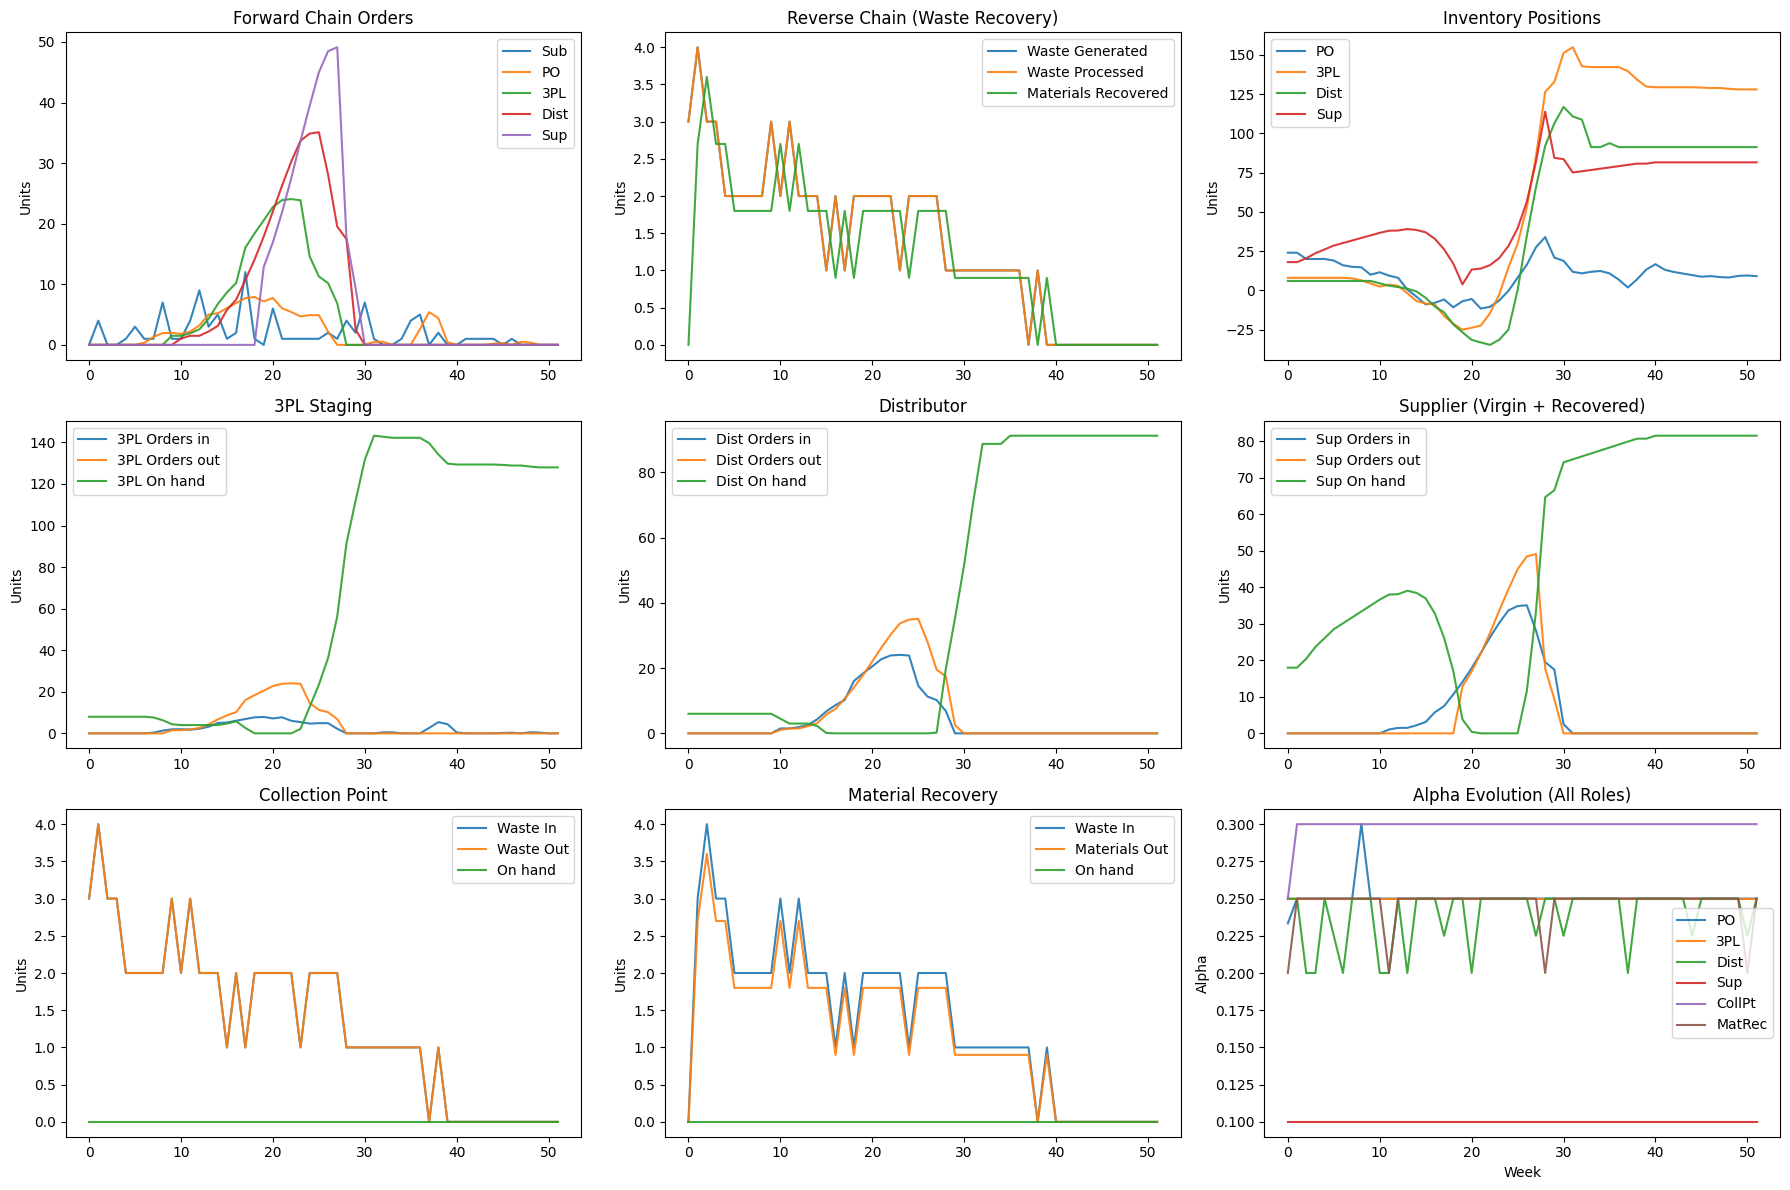


BULLWHIP ANALYSIS:
Customer demand variance (baseline): 6.79

Bullwhip ratios (Order variance / Customer variance):
Sub    : 1.00
PO     : 1.15
3PL    : 9.69
Dist   : 19.43
Sup    : 31.92

Waste generation variance: 0.76
Waste processing ratios (Order variance / Waste variance):
CollPt : 1.00
MatRec : 0.87


In [ ]:
# ===== Post-Run Diagnostics (MULTI-PROJECT CLOSED LOOP) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _roles_by_prefix(prefixes):
    return [r for r in ROLES if any(r == p or r.startswith(p) for p in prefixes)]

# Extended groupings for multi-project closed-loop supply chain
SUBS      = _roles_by_prefix(["Sub"])
POS_      = _roles_by_prefix(["PO"])
THREEPLS  = _roles_by_prefix(["3PL"])
DISTS_    = _roles_by_prefix(["Dist"])
SUPS_     = _roles_by_prefix(["Sup"])
COLLPTS_  = _roles_by_prefix(["CollPoint"])  # Collection Points
MATRECOVS = _roles_by_prefix(["MatRecov"])   # Material Recovery

def _sum_series(role_list, series_dict):
    if not role_list:
        return None
    arrs = [np.asarray(series_dict[r], dtype=float) for r in role_list]
    return np.sum(arrs, axis=0)

def _avg_coeff(role_list, coeff_logs, key):
    vals = []
    for r in role_list:
        if r in coeff_logs and coeff_logs[r]:
            vals.extend([float(c[key]) for c in coeff_logs[r] if key in c])
    return (np.mean(vals) if vals else np.nan)

def _count_true(role_list, coeff_logs, key):
    cnt = 0
    for r in role_list:
        if r in coeff_logs and coeff_logs[r]:
            cnt += sum(bool(c.get(key, False)) for c in coeff_logs[r])
    return cnt

if 'hist_roles' in globals() and 'coeff_logs' in globals():
    T = len(next(iter(hist_roles["on_hand"].values())))
    weeks_to_check = [w for w in [0, 10, 20, 30, 40, 50] if w < T]

    # ---------- ORDER ACTIVITY (category totals) ----------
    print("ORDER ACTIVITY (category totals):")
    cat_map = {
        "Sub":     SUBS,
        "PO":      POS_,
        "3PL":     THREEPLS,
        "Dist":    DISTS_,
        "Sup":     SUPS_,
        "CollPt":  COLLPTS_,   # Collection Points
        "MatRec":  MATRECOVS,  # Material Recovery
    }
    for cat, roles in cat_map.items():
        series = _sum_series(roles, hist_roles["orders_out"])
        if series is None:
            continue
        total_orders = series.sum()
        non_zero_weeks = int((series > 0.1).sum())
        max_order = float(series.max())
        print(f"{cat:7s}: Total={total_orders:7.1f}, Active_weeks={non_zero_weeks:2d}/{T}, Max={max_order:7.1f}")

    # ---------- CLOSED-LOOP FLOW ANALYSIS ----------
    print("\nCLOSED-LOOP FLOW ANALYSIS:")
    # Waste generation and recovery metrics
    if "waste_in" in hist_roles and SUBS:
        total_waste_generated = float(_sum_series(SUBS, hist_roles["waste_in"]).sum())
        print(f"Total waste generated by contractors: {total_waste_generated:.1f} units")

        if COLLPTS_:
            waste_collected = float(_sum_series(COLLPTS_, hist_roles["orders_in"]).sum())
            collection_rate = (waste_collected / total_waste_generated * 100) if total_waste_generated > 0 else 0
            print(f"Total waste collected: {waste_collected:.1f} units ({collection_rate:.1f}% of generated)")

        if MATRECOVS:
            materials_recovered = float(_sum_series(MATRECOVS, hist_roles["orders_out"]).sum())
            recovery_rate = (materials_recovered / waste_collected * 100) if waste_collected > 0 else 0
            print(f"Total materials recovered: {materials_recovered:.1f} units ({recovery_rate:.1f}% of collected)")

            # How much did recovered materials contribute to supplier inventory?
            if SUPS_:
                total_sup_orders = float(_sum_series(SUPS_, hist_roles["orders_in"]).sum())
                recovery_contribution = (materials_recovered / total_sup_orders * 100) if total_sup_orders > 0 else 0
                print(f"Recovery contribution to supplier: {recovery_contribution:.1f}% of supplier input")

    # ---------- WEEKLY ORDER PATTERNS (category totals) ----------
    print("\nWEEKLY ORDER PATTERNS (category totals):")
    order_rows = []
    for t in weeks_to_check:
        row = {"week": t}
        for cat, roles in cat_map.items():
            s = _sum_series(roles, hist_roles["orders_out"])
            if s is not None:
                row[f"{cat}_order"] = float(s[t])
        order_rows.append(row)
    df_orders = pd.DataFrame(order_rows)
    with pd.option_context('display.float_format', lambda x: f"{x:7.1f}"):
        print(df_orders.to_string(index=False))

    # ---------- INVENTORY ANALYSIS (all categories) ----------
    print("\nINVENTORY ANALYSIS (category totals):")
    for cat, roles in [("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_), ("CollPt", COLLPTS_), ("MatRec", MATRECOVS)]:
        on_hand  = _sum_series(roles, hist_roles["on_hand"])
        backlog  = _sum_series(roles, hist_roles["backlog"])
        pipeline = _sum_series(roles, hist_roles["pipeline"])
        if on_hand is None:
            continue
        inv_pos = on_hand + pipeline - backlog
        wk = weeks_to_check[2] if len(weeks_to_check) >= 3 else weeks_to_check[-1]
        print(f"\n{cat}:")
        print(f"  Week {wk:2d}: on_hand={on_hand[wk]:.1f}, backlog={backlog[wk]:.1f}, pipeline={pipeline[wk]:.1f}")
        print(f"  Week {wk:2d}: inv_pos={inv_pos[wk]:.1f}")
        start = min(10, T-1)
        print(f"  Avg inventory (weeks {start}-{T-1}): {on_hand[start:].mean():.1f}")

    # ---------- COEFFICIENT ANALYSIS (averaged by category) ----------
    print("\nCOEFFICIENT ANALYSIS (category averages):")
    for cat, roles in cat_map.items():
        a = _avg_coeff(roles, coeff_logs, "alpha")
        s = _avg_coeff(roles, coeff_logs, "service_level")
        l = _avg_coeff(roles, coeff_logs, "lot_multiplier")
        e = _count_true(roles, coeff_logs, "expedite")
        if not np.isnan(a):
            print(f"{cat:7s}: alpha={a:.2f}, service={s:.2f}, lot={l:.2f}, expedites={e}")

    # ---------- SUPPLY CHAIN FLOW (category totals) ----------
    print("\nSUPPLY CHAIN FLOW (category totals):")
    flow_rows = []
    for t in [w for w in [10, 20, 30, 40] if w < T]:
        row = {"week": t}
        # Forward chain flows
        row["Sub_out"] = float(_sum_series(SUBS, hist_roles["orders_out"])[t]) if SUBS else 0.0
        row["PO_in"]  = float(_sum_series(POS_, hist_roles["orders_in"])[t])  if POS_ else 0.0
        row["PO_out"] = float(_sum_series(POS_, hist_roles["orders_out"])[t]) if POS_ else 0.0
        row["3PL_in"]  = float(_sum_series(THREEPLS, hist_roles["orders_in"])[t])  if THREEPLS else 0.0
        row["3PL_out"] = float(_sum_series(THREEPLS, hist_roles["orders_out"])[t]) if THREEPLS else 0.0
        row["Dist_in"]  = float(_sum_series(DISTS_, hist_roles["orders_in"])[t])  if DISTS_ else 0.0
        row["Dist_out"] = float(_sum_series(DISTS_, hist_roles["orders_out"])[t]) if DISTS_ else 0.0
        row["Sup_in"] = float(_sum_series(SUPS_, hist_roles["orders_in"])[t]) if SUPS_ else 0.0
        # Reverse chain flows (waste)
        if "waste_in" in hist_roles and SUBS:
            row["Waste_gen"] = float(_sum_series(SUBS, hist_roles["waste_in"])[t])
        row["Coll_out"] = float(_sum_series(COLLPTS_, hist_roles["orders_out"])[t]) if COLLPTS_ else 0.0
        row["Rec_out"] = float(_sum_series(MATRECOVS, hist_roles["orders_out"])[t]) if MATRECOVS else 0.0
        flow_rows.append(row)
    df_flow = pd.DataFrame(flow_rows)
    with pd.option_context('display.float_format', lambda x: f"{x:7.1f}"):
        print(df_flow.to_string(index=False))

    # ---------- PLOTS (category totals) ----------
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))

    # Plot 1: Orders Out by Category (Forward Chain)
    ax = axes[0,0]
    for cat, roles in [("Sub", SUBS), ("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        s = _sum_series(roles, hist_roles["orders_out"])
        if s is not None:
            ax.plot(s, label=cat, alpha=0.9)
    ax.set_title("Forward Chain Orders"); ax.legend(); ax.set_ylabel("Units")

    # Plot 2: Reverse Chain Flow
    ax = axes[0,1]
    if "waste_in" in hist_roles and SUBS:
        ax.plot(_sum_series(SUBS, hist_roles["waste_in"]), label="Waste Generated", alpha=0.9)
    if COLLPTS_:
        ax.plot(_sum_series(COLLPTS_, hist_roles["orders_out"]), label="Waste Processed", alpha=0.9)
    if MATRECOVS:
        ax.plot(_sum_series(MATRECOVS, hist_roles["orders_out"]), label="Materials Recovered", alpha=0.9)
    ax.set_title("Reverse Chain (Waste Recovery)"); ax.legend(); ax.set_ylabel("Units")

    # Plot 3: Inventory Positions
    ax = axes[0,2]
    for cat, roles in [("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_)]:
        oh = _sum_series(roles, hist_roles["on_hand"])
        bl = _sum_series(roles, hist_roles["backlog"])
        pl = _sum_series(roles, hist_roles["pipeline"])
        if oh is None:
            continue
        inv_pos = oh + pl - bl
        ax.plot(inv_pos, label=cat, alpha=0.9)
    ax.set_title("Inventory Positions"); ax.legend(); ax.set_ylabel("Units")

    # Plot 4: 3PL Staging
    ax = axes[1,0]
    if THREEPLS:
        ax.plot(_sum_series(THREEPLS, hist_roles["orders_in"]),  label="3PL Orders in",  alpha=0.9)
        ax.plot(_sum_series(THREEPLS, hist_roles["orders_out"]), label="3PL Orders out", alpha=0.9)
        ax.plot(_sum_series(THREEPLS, hist_roles["on_hand"]),    label="3PL On hand",    alpha=0.9)
    ax.set_title("3PL Staging"); ax.legend(); ax.set_ylabel("Units")

    # Plot 5: Distributor
    ax = axes[1,1]
    if DISTS_:
        ax.plot(_sum_series(DISTS_, hist_roles["orders_in"]),  label="Dist Orders in",  alpha=0.9)
        ax.plot(_sum_series(DISTS_, hist_roles["orders_out"]), label="Dist Orders out", alpha=0.9)
        ax.plot(_sum_series(DISTS_, hist_roles["on_hand"]),    label="Dist On hand",    alpha=0.9)
    ax.set_title("Distributor"); ax.legend(); ax.set_ylabel("Units")

    # Plot 6: Supplier (now shows both virgin and recovered materials)
    ax = axes[1,2]
    if SUPS_:
        ax.plot(_sum_series(SUPS_, hist_roles["orders_in"]),  label="Sup Orders in",  alpha=0.9)
        ax.plot(_sum_series(SUPS_, hist_roles["orders_out"]), label="Sup Orders out", alpha=0.9)
        ax.plot(_sum_series(SUPS_, hist_roles["on_hand"]),    label="Sup On hand",    alpha=0.9)
    ax.set_title("Supplier (Virgin + Recovered)"); ax.legend(); ax.set_ylabel("Units")

    # Plot 7: Collection Point
    ax = axes[2,0]
    if COLLPTS_:
        ax.plot(_sum_series(COLLPTS_, hist_roles["orders_in"]),  label="Waste In",  alpha=0.9)
        ax.plot(_sum_series(COLLPTS_, hist_roles["orders_out"]), label="Waste Out", alpha=0.9)
        ax.plot(_sum_series(COLLPTS_, hist_roles["on_hand"]),    label="On hand",    alpha=0.9)
    ax.set_title("Collection Point"); ax.legend(); ax.set_ylabel("Units")

    # Plot 8: Material Recovery
    ax = axes[2,1]
    if MATRECOVS:
        ax.plot(_sum_series(MATRECOVS, hist_roles["orders_in"]),  label="Waste In",  alpha=0.9)
        ax.plot(_sum_series(MATRECOVS, hist_roles["orders_out"]), label="Materials Out", alpha=0.9)
        ax.plot(_sum_series(MATRECOVS, hist_roles["on_hand"]),    label="On hand",    alpha=0.9)
    ax.set_title("Material Recovery"); ax.legend(); ax.set_ylabel("Units")

    # Plot 9: Alpha Evolution
    ax = axes[2,2]
    for cat, roles in [("PO", POS_), ("3PL", THREEPLS), ("Dist", DISTS_), ("Sup", SUPS_), ("CollPt", COLLPTS_), ("MatRec", MATRECOVS)]:
        alphas_per_role = []
        for r in roles:
            if r in coeff_logs and coeff_logs[r]:
                alphas_per_role.append([c["alpha"] for c in coeff_logs[r]])
        if not alphas_per_role:
            continue
        min_len = min(len(a) for a in alphas_per_role)
        if min_len == 0:
            continue
        arr = np.array([a[:min_len] for a in alphas_per_role], dtype=float)
        ax.plot(arr.mean(axis=0), label=cat, alpha=0.9)
    ax.set_title("Alpha Evolution (All Roles)"); ax.legend(); ax.set_ylabel("Alpha"); ax.set_xlabel("Week")

    plt.tight_layout()
    plt.show()

    # ---------- BULLWHIP ANALYSIS ----------
    print("\nBULLWHIP ANALYSIS:")
    demand_vars = {}
    order_vars = {}

    for cat, roles in cat_map.items():
        orders = _sum_series(roles, hist_roles["orders_out"])
        if orders is not None and len(orders) > 10:
            # Calculate variance from week 10 onwards (after initial stabilization)
            order_vars[cat] = float(np.var(orders[10:]))

    # Customer demand variance as baseline
    if len(customerDemand_total) > 10:
        customer_var = float(np.var(customerDemand_total[10:]))
        print(f"Customer demand variance (baseline): {customer_var:.2f}")

        print("\nBullwhip ratios (Order variance / Customer variance):")
        for cat in ["Sub", "PO", "3PL", "Dist", "Sup"]:
            if cat in order_vars:
                bullwhip = order_vars[cat] / customer_var if customer_var > 0 else float('inf')
                print(f"{cat:7s}: {bullwhip:.2f}")

        # Reverse chain doesn't follow customer demand, so separate analysis
        if len(projectWaste_total) > 10:
            waste_var = float(np.var(projectWaste_total[10:]))
            print(f"\nWaste generation variance: {waste_var:.2f}")
            print("Waste processing ratios (Order variance / Waste variance):")
            for cat in ["CollPt", "MatRec"]:
                if cat in order_vars:
                    waste_ratio = order_vars[cat] / waste_var if waste_var > 0 else float('inf')
                    print(f"{cat:7s}: {waste_ratio:.2f}")

else:
    print("Run the simulation first to generate hist_roles and coeff_logs data.")

Forward Chain Bullwhip metrics (post burn-in = 10):
  role  bullwhip_ratio_var  amplification_std  mean_ratio
 3PL_A               2.418              1.555       1.258
 3PL_B               3.116              1.765       1.494
Dist_A               4.611              2.147       1.768
Dist_B               6.746              2.597       2.029
   PO1               0.417              0.646       0.792
   PO2               0.097              0.311       0.311
   PO3               0.038              0.194       0.153
  Sub1               0.323              0.569       0.639
  Sub2               0.093              0.305       0.241
  Sub3               0.034              0.184       0.120
   Sup              31.921              5.650       3.879

Reverse Chain metrics vs waste generation (post burn-in = 10):
     role  bullwhip_ratio_var  amplification_std  mean_ratio
CollPoint               1.000              1.000       1.000
 MatRecov               0.873              0.935       0.961

=== 

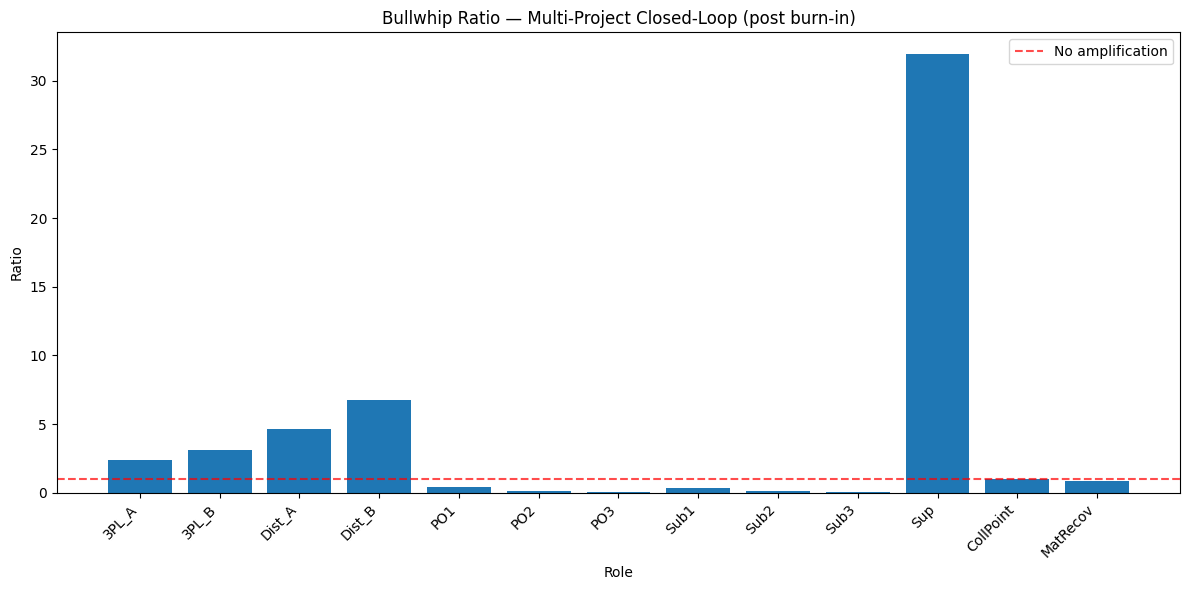

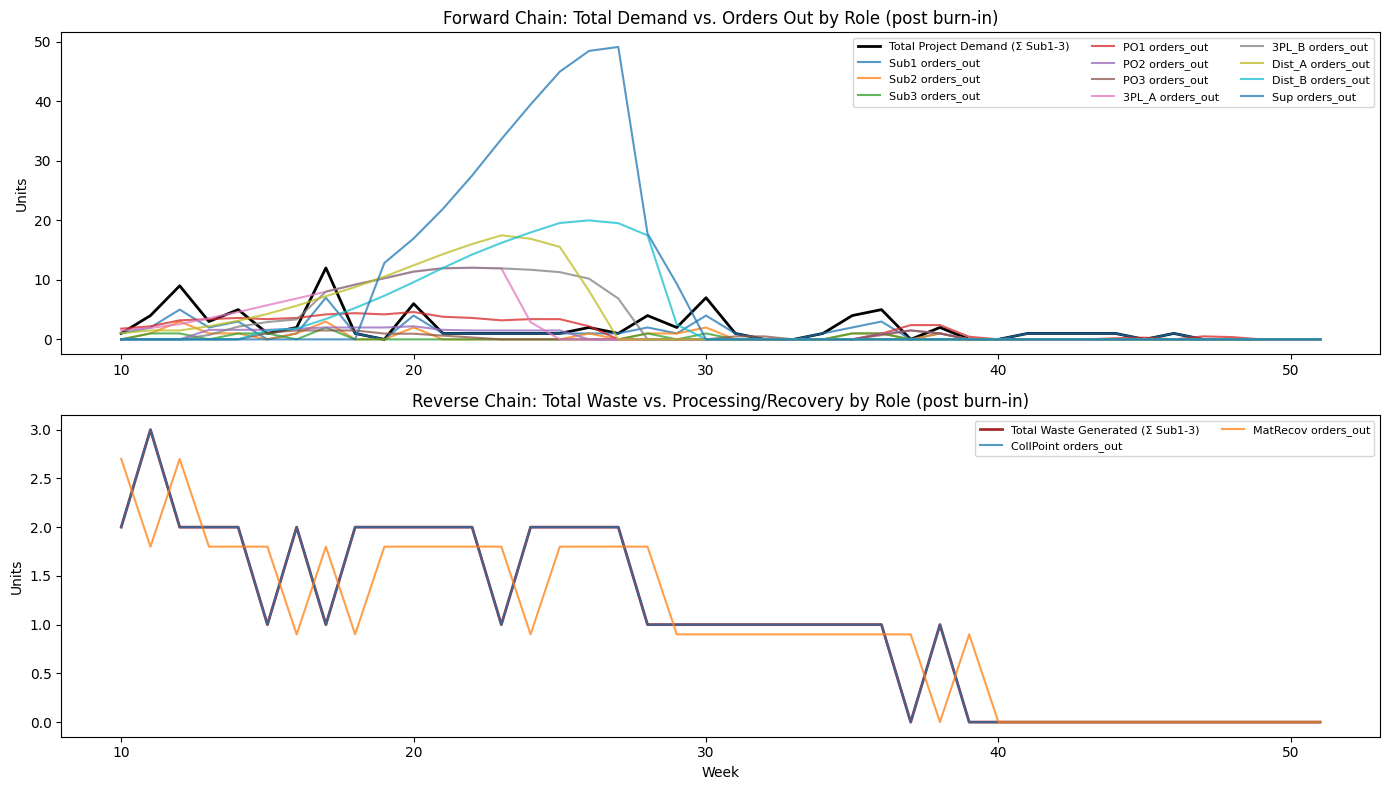

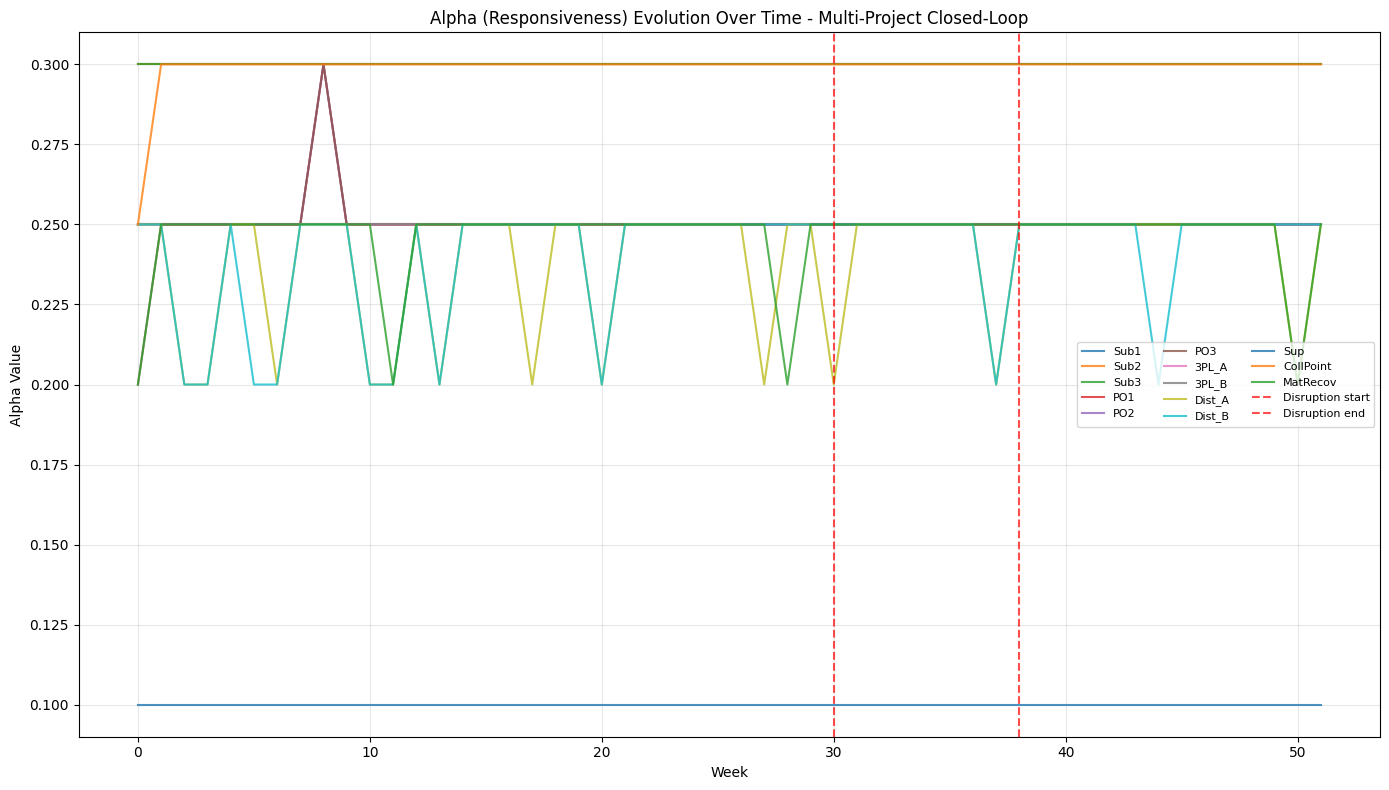

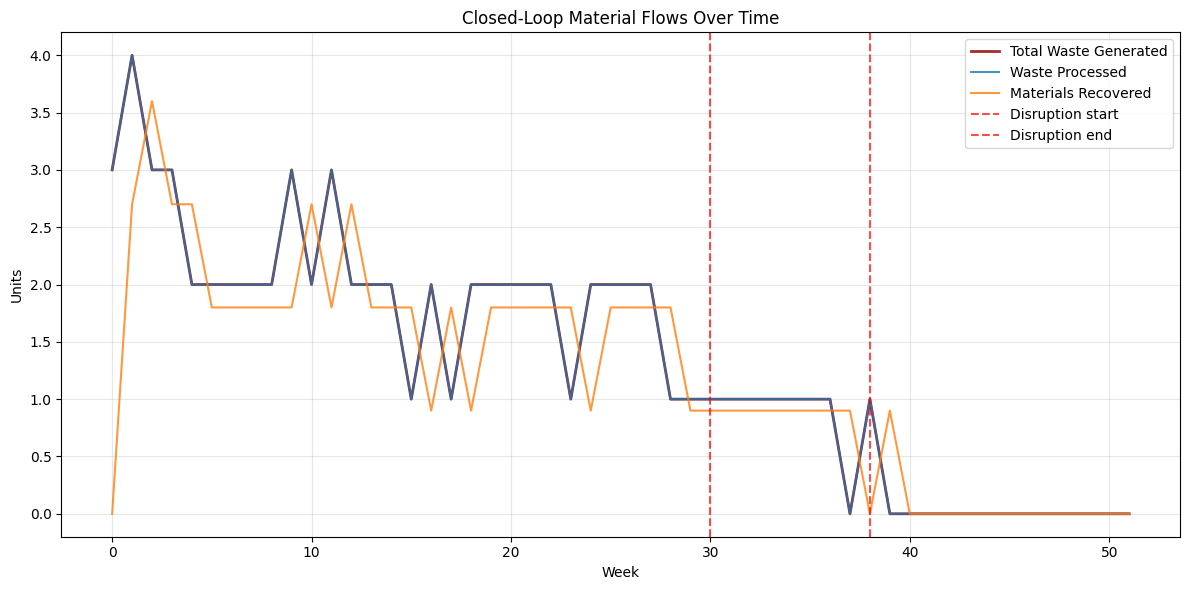

In [ ]:
# ===== R5 — KPIs + coefficient & sharing summaries (multi-project closed-loop) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

burnIn = 10  # exclude first 10 weeks from analysis

# --- Role groups taken from the run objects ---
SUBS   = [k for k in hist_roles["orders_out"].keys() if k.startswith("Sub")]
POS    = [k for k in hist_roles["orders_out"].keys() if k.startswith("PO")]
THREEP = [k for k in hist_roles["orders_out"].keys() if k.startswith("3PL_")]
DISTS  = [k for k in hist_roles["orders_out"].keys() if k.startswith("Dist_")]
SUPS   = ["Sup"]
COLLPT = [k for k in hist_roles["orders_out"].keys() if k.startswith("CollPoint")]
MATREC = [k for k in hist_roles["orders_out"].keys() if k.startswith("MatRecov")]
ALL_ROLES = SUBS + POS + THREEP + DISTS + SUPS + COLLPT + MATREC

# Roles that hold inventory / place orders
roles_holding = ALL_ROLES

# --- Demand: total customer demand across the three projects
# Uses the per-sub series defined in R1; assert the sum equals original total.
d_total = np.zeros(horizonWeeks, dtype=float)
for s in SUBS:
    d_total += np.asarray(customerDemand_by_sub[s], dtype=float)

# Waste: total waste generated across the three projects
w_total = np.zeros(horizonWeeks, dtype=float)
for s in SUBS:
    w_total += np.asarray(projectWaste_by_sub[s], dtype=float)

try:
    assert np.allclose(d_total, customerDemand_total)
    assert np.allclose(w_total, projectWaste_total)
except Exception:
    pass

def compute_metrics_roles(hist, demand_series, roles, burnIn=0):
    rows = []
    cust = np.asarray(demand_series[burnIn:], dtype=float)
    var_cust = float(np.var(cust, ddof=0))
    std_cust = float(np.std(cust, ddof=0))
    mean_cust = float(np.mean(cust))

    for r in roles:
        orders = np.asarray(hist["orders_out"][r][burnIn:], dtype=float)
        var_orders = float(np.var(orders, ddof=0))
        std_orders = float(np.std(orders, ddof=0))
        mean_orders = float(np.mean(orders))

        rows.append({
            "role": r,
            "bullwhip_ratio_var": (var_orders / var_cust) if var_cust > 0 else np.nan,
            "amplification_std": (std_orders / std_cust) if std_cust > 0 else np.nan,
            "mean_ratio": (mean_orders / mean_cust) if mean_cust > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("role")

# ---- KPIs for forward chain (use demand baseline)
forward_roles = SUBS + POS + THREEP + DISTS + SUPS
df_kpi_forward = compute_metrics_roles(hist_roles, d_total, forward_roles, burnIn=burnIn)
print(f"Forward Chain Bullwhip metrics (post burn-in = {burnIn}):")
print(df_kpi_forward.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- KPIs for reverse chain (use waste baseline)
reverse_roles = COLLPT + MATREC
if reverse_roles:
    df_kpi_reverse = compute_metrics_roles(hist_roles, w_total, reverse_roles, burnIn=burnIn)
    print(f"\nReverse Chain metrics vs waste generation (post burn-in = {burnIn}):")
    print(df_kpi_reverse.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- Closed-loop efficiency metrics
print("\n=== CLOSED-LOOP EFFICIENCY METRICS ===")
if "waste_in" in hist_roles and SUBS:
    total_waste_generated = float(sum(np.asarray(hist_roles["waste_in"][s], dtype=float).sum() for s in SUBS))
    print(f"Total waste generated: {total_waste_generated:.1f} units")

    if COLLPT:
        waste_collected = float(sum(np.asarray(hist_roles["orders_in"][c], dtype=float).sum() for c in COLLPT))
        collection_efficiency = (waste_collected / total_waste_generated * 100) if total_waste_generated > 0 else 0
        print(f"Total waste collected: {waste_collected:.1f} units ({collection_efficiency:.1f}% efficiency)")

    if MATREC:
        materials_recovered = float(sum(np.asarray(hist_roles["orders_out"][m], dtype=float).sum() for m in MATREC))
        recovery_efficiency = (materials_recovered / waste_collected * 100) if waste_collected > 0 else 0
        print(f"Total materials recovered: {materials_recovered:.1f} units ({recovery_efficiency:.1f}% efficiency)")

        # Recovery contribution to supplier
        total_sup_orders = float(sum(np.asarray(hist_roles["orders_in"][s], dtype=float).sum() for s in SUPS))
        recovery_contribution = (materials_recovered * 0.90 / total_sup_orders * 100) if total_sup_orders > 0 else 0  # 90% recovery rate
        print(f"Recovery contribution to supplier: {recovery_contribution:.1f}% of supplier input")

# ---- Coefficient logs → DataFrame
rows = []
for r, logs in coeff_logs.items():
    for rec in logs:
        rows.append({
            "role": r,
            **{k: rec.get(k) for k in ("t","alpha","service_level","lot_multiplier","expedite")}
        })
coeff_df = pd.DataFrame(rows).sort_values(["role","t"])
print("\nSample of coefficient choices:")
print(coeff_df.head(21).to_string(index=False))  # show more given more roles

# Distributions by role
alpha_dist = coeff_df.groupby(["role","alpha"]).size().rename("count").reset_index()
sl_dist    = coeff_df.groupby(["role","service_level"]).size().rename("count").reset_index()
lot_dist   = coeff_df.groupby(["role","lot_multiplier"]).size().rename("count").reset_index()
exp_dist   = coeff_df.groupby(["role","expedite"]).size().rename("count").reset_index()

print("\nAlpha choices (counts):")
print(alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int))
print("\nService level choices (counts):")
print(sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int))
print("\nLot multiplier choices (counts):")
print(lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int))
print("\nExpedite choices (counts):")
print(exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int))

# ---- Sharing policy changes summary
policy_rows = []
for r, logs in coeff_logs.items():
    add_total = sum(len(rec.get("share_add", [])) for rec in logs)
    drop_total = sum(len(rec.get("share_drop", [])) for rec in logs)
    policy_rows.append({"role": r, "share_add_total": add_total, "share_drop_total": drop_total})
df_policy = pd.DataFrame(policy_rows).sort_values("role")
print("\nSharing policy changes (totals over run):")
print(df_policy.to_string(index=False))

# Current published keys by role (from InfoBank policies)
current_share = {r: profiles[r].share_keys for r in ROLES}
print("\nCurrent share policy keys by role:")
for r in ROLES:
    print(f"  {r}: {current_share[r]}")

# ---- Enhanced Analysis tuned to multi-project closed-loop topology
print("\n=== MULTI-PROJECT CLOSED-LOOP ANALYSIS ===")

# Role-specific coefficient averages
print("\nAverage coefficients by role:")
role_avg_coeffs = coeff_df.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
print(role_avg_coeffs.round(3))

# Expedite frequency by role
print("\nExpedite frequency by role:")
expedite_freq = coeff_df.groupby("role")["expedite"].mean()
print(expedite_freq.round(3))

# Pre-crisis vs Crisis vs Post-crisis comparison
periods = {
    "pre_crisis": (0, 30),
    "crisis": (30, 38),
    "post_crisis": (38, 52)
}

print("\nPeriod-based coefficient analysis:")
for period_name, (start, end) in periods.items():
    period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
    if len(period_data) > 0:
        print(f"\n{period_name.upper()}:")
        period_avg = period_data.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
        print(period_avg.round(3))

# ---- Plots
# 1) Bullwhip ratio bar across all concrete roles
plt.figure(figsize=(12,6))
all_roles_kpi = pd.concat([df_kpi_forward, df_kpi_reverse if reverse_roles else pd.DataFrame()])
plt.bar(all_roles_kpi["role"], all_roles_kpi["bullwhip_ratio_var"])
plt.axhline(1.0, linestyle="--", color='red', alpha=0.7, label='No amplification')
plt.title("Bullwhip Ratio — Multi-Project Closed-Loop (post burn-in)")
plt.ylabel("Ratio"); plt.xlabel("Role")
plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

# 2) Orders_out vs. total demand/waste (post burn-in)
t_idx = np.arange(horizonWeeks)
plt.figure(figsize=(14,8))
plt.subplot(2,1,1)
plt.plot(t_idx[burnIn:], d_total[burnIn:], label="Total Project Demand (Σ Sub1-3)", linewidth=2, color='black')
for r in forward_roles:
    plt.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:], label=f"{r} orders_out", alpha=0.75)
plt.title("Forward Chain: Total Demand vs. Orders Out by Role (post burn-in)")
plt.ylabel("Units")
plt.legend(ncol=3, fontsize=8)

plt.subplot(2,1,2)
plt.plot(t_idx[burnIn:], w_total[burnIn:], label="Total Waste Generated (Σ Sub1-3)", linewidth=2, color='brown')
for r in reverse_roles:
    plt.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:], label=f"{r} orders_out", alpha=0.75)
plt.title("Reverse Chain: Total Waste vs. Processing/Recovery by Role (post burn-in)")
plt.xlabel("Week"); plt.ylabel("Units")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

# 3) Alpha evolution by role (all roles)
plt.figure(figsize=(14,8))
for r in roles_holding:
    if r in coeff_logs and coeff_logs[r]:
        times = [rec["t"] for rec in coeff_logs[r]]
        alphas = [rec["alpha"] for rec in coeff_logs[r]]
        plt.plot(times, alphas, label=f"{r}", alpha=0.8)
plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
plt.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
plt.title("Alpha (Responsiveness) Evolution Over Time - Multi-Project Closed-Loop")
plt.xlabel("Week"); plt.ylabel("Alpha Value")
plt.legend(fontsize=8, ncol=3); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 4) Closed-loop flows over time
plt.figure(figsize=(12,6))
if "waste_in" in hist_roles and SUBS:
    total_waste_ts = np.sum([np.asarray(hist_roles["waste_in"][s], dtype=float) for s in SUBS], axis=0)
    plt.plot(total_waste_ts, label="Total Waste Generated", linewidth=2, color='brown')

if COLLPT:
    total_collected_ts = np.sum([np.asarray(hist_roles["orders_out"][c], dtype=float) for c in COLLPT], axis=0)
    plt.plot(total_collected_ts, label="Waste Processed", alpha=0.8)

if MATREC:
    total_recovered_ts = np.sum([np.asarray(hist_roles["orders_out"][m], dtype=float) for m in MATREC], axis=0)
    plt.plot(total_recovered_ts, label="Materials Recovered", alpha=0.8)

plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
plt.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
plt.title("Closed-Loop Material Flows Over Time")
plt.xlabel("Week"); plt.ylabel("Units")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---- Optional: save summaries
# coeff_df.to_csv("coeff_choices_multi_closed_loop.csv", index=False)
# all_roles_kpi.to_csv("kpi_bullwhip_multi_closed_loop.csv", index=False)
# df_policy.to_csv("sharing_changes_multi_closed_loop.csv", index=False)

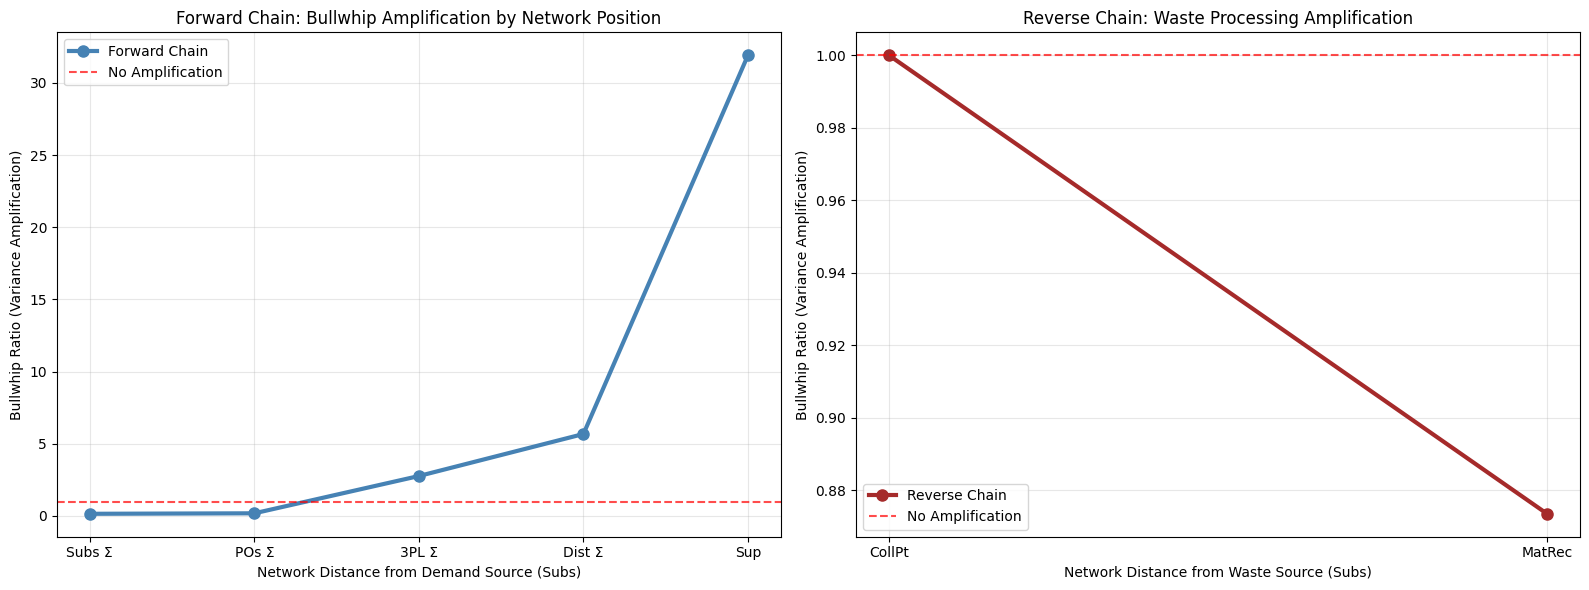

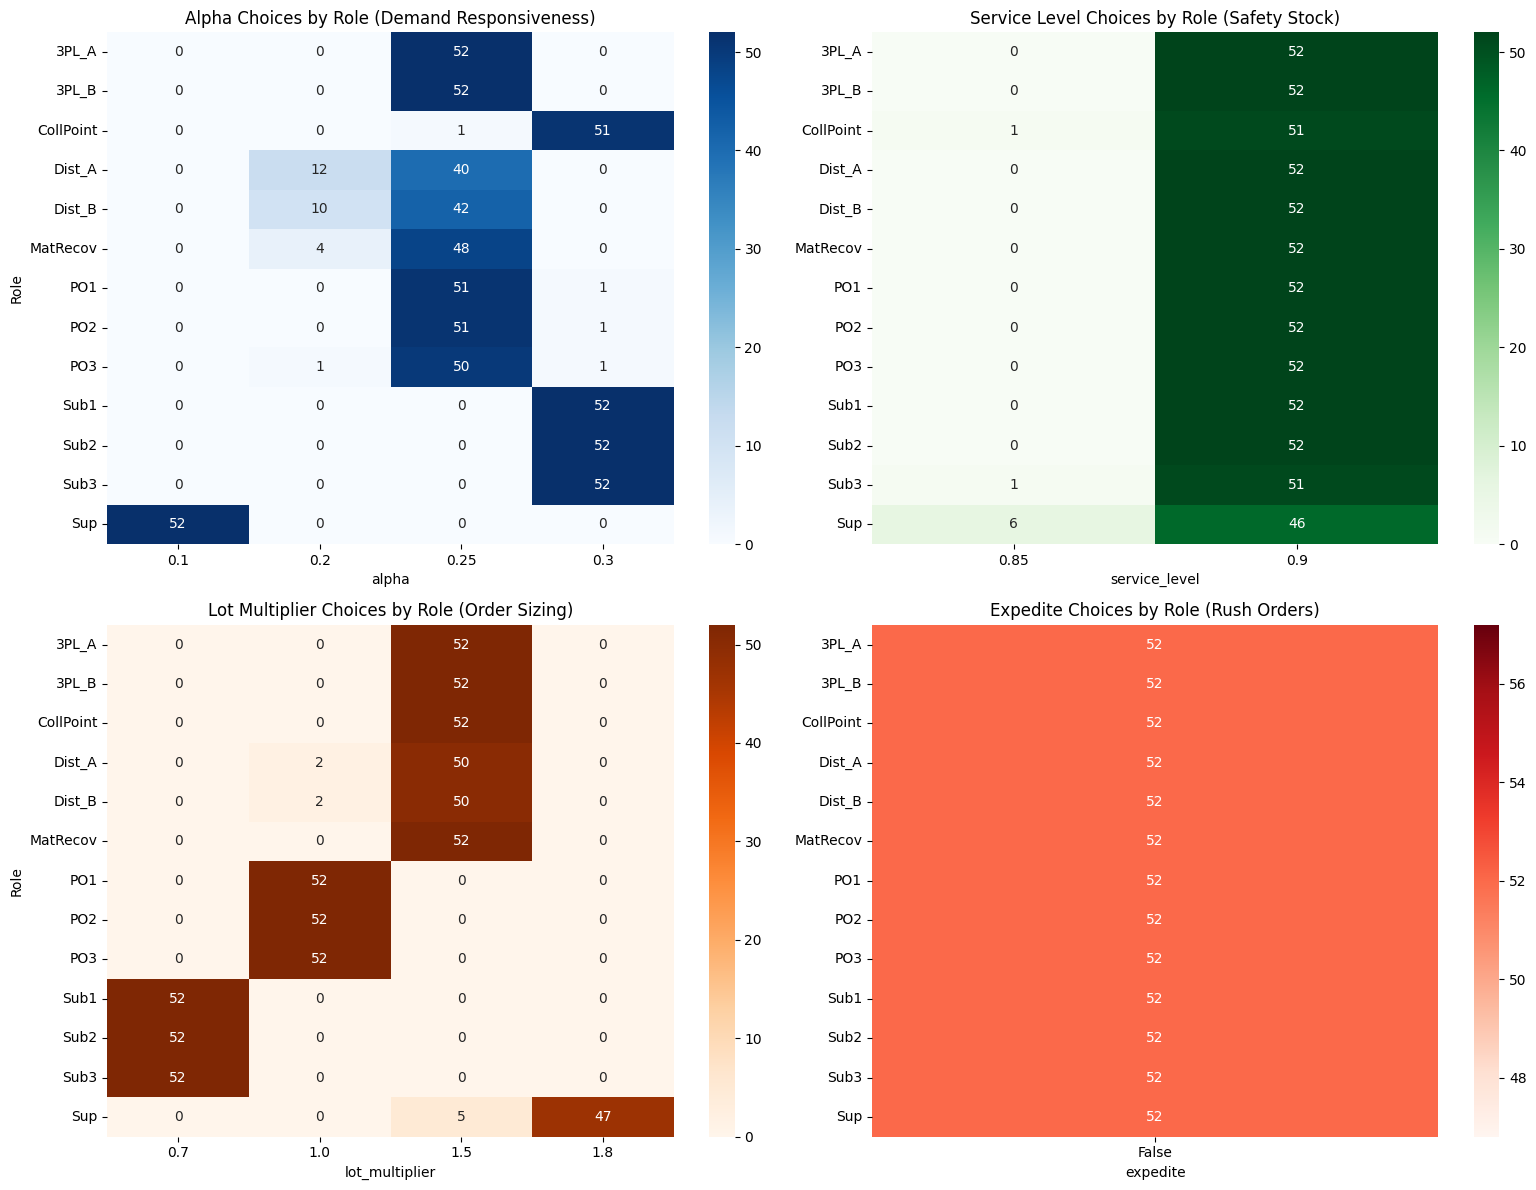

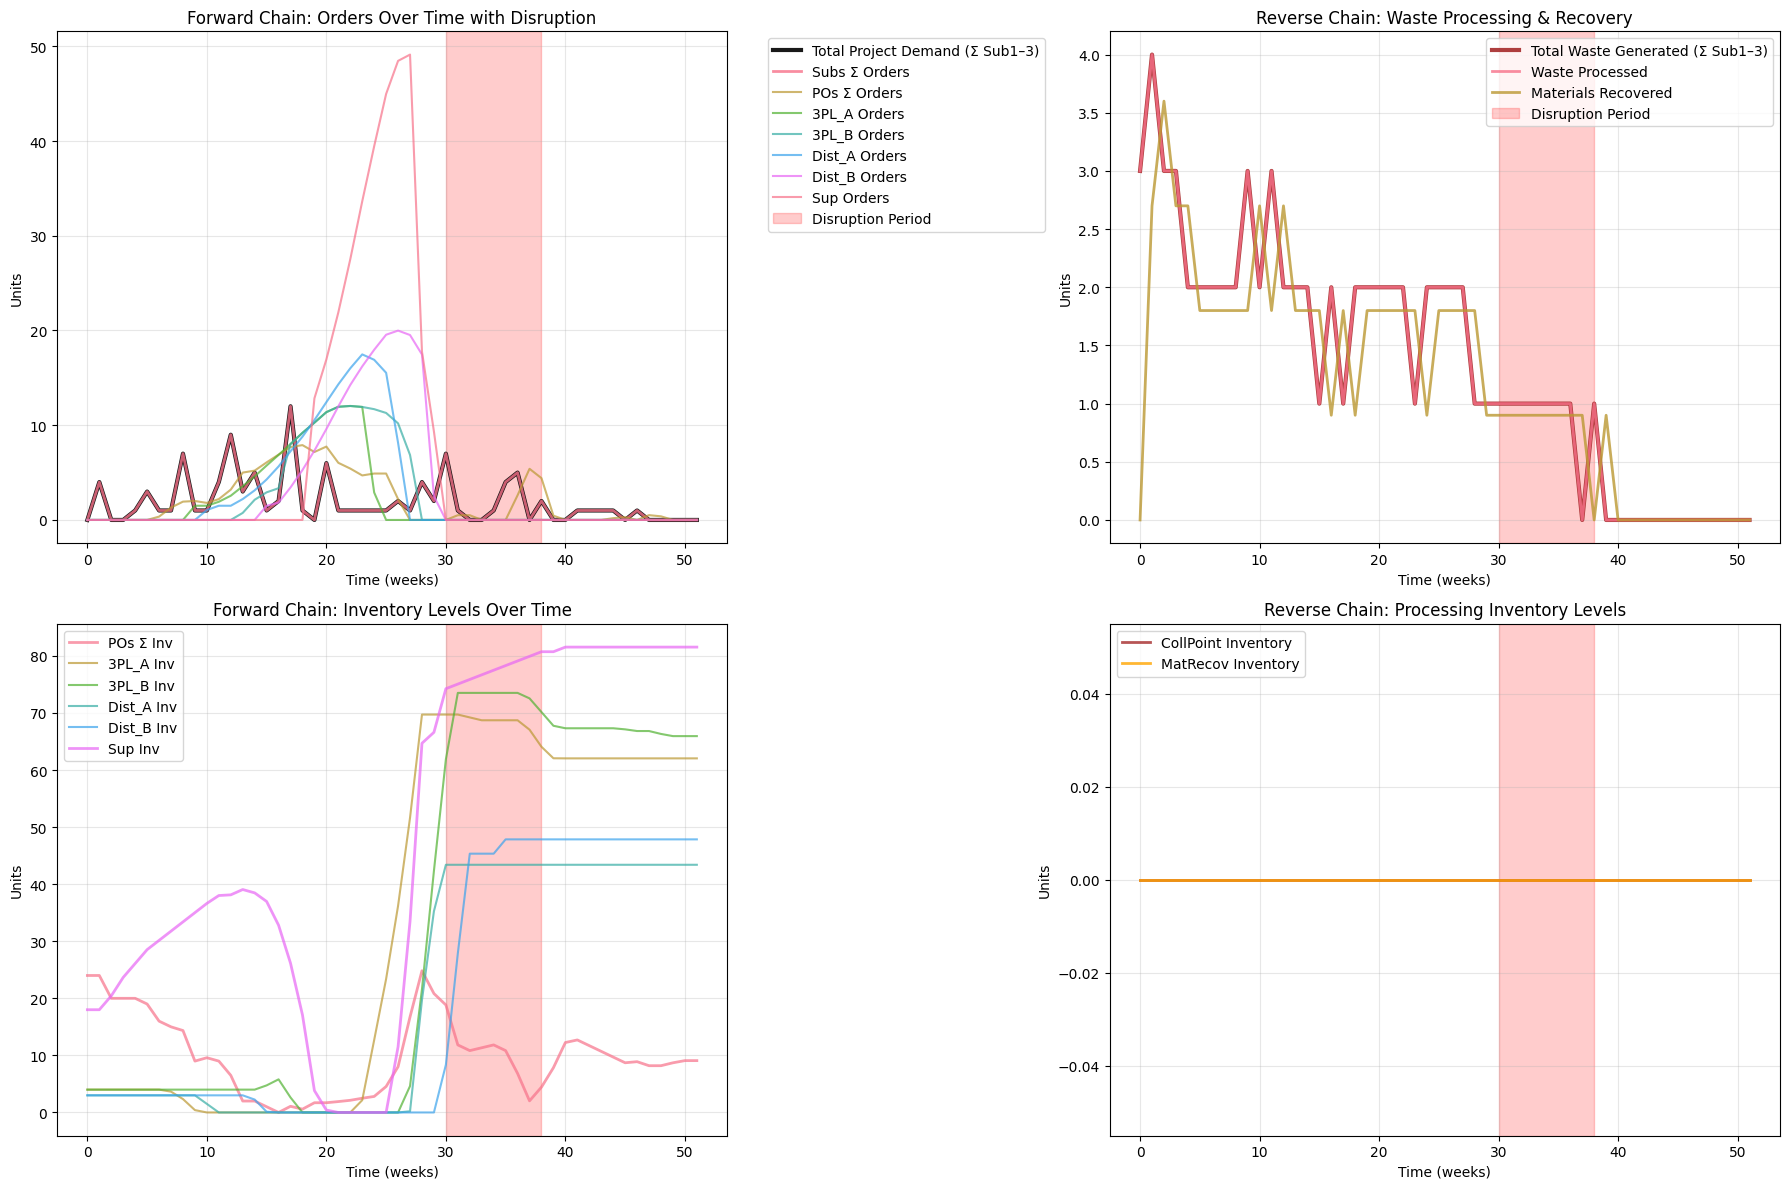

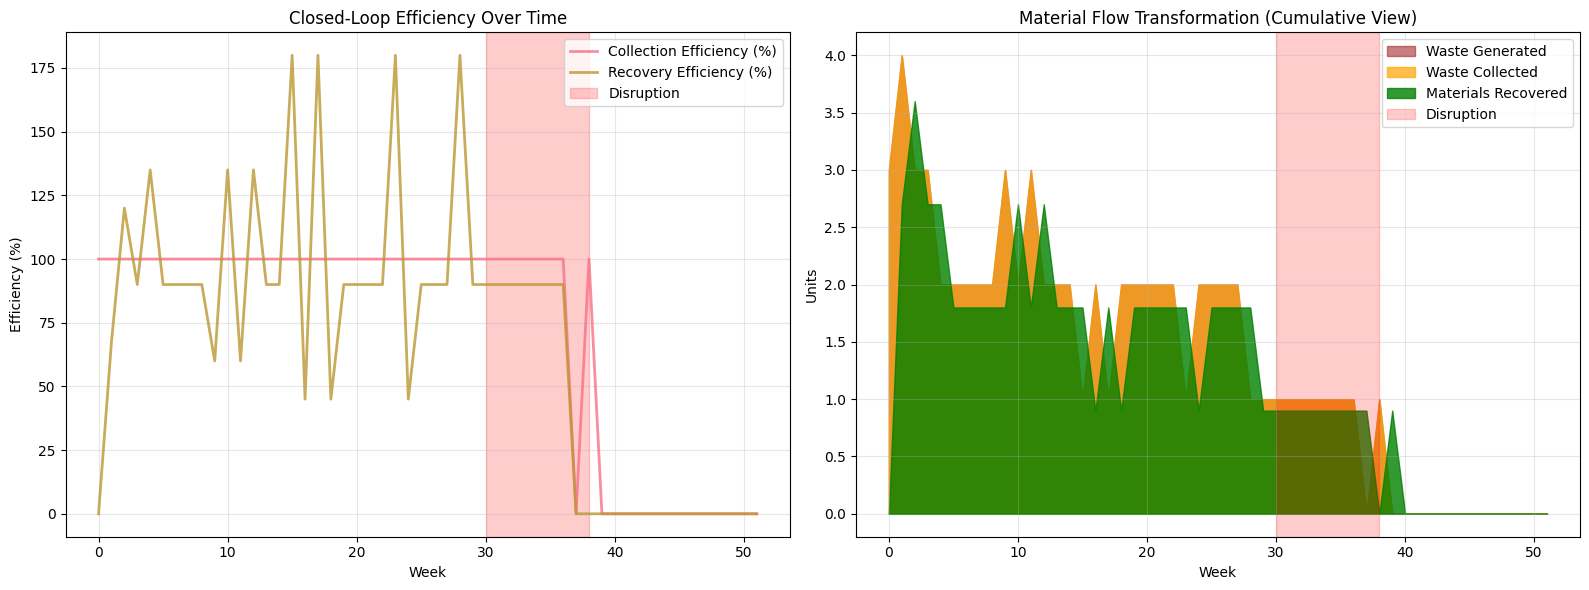

/tmp/ipython-input-1560664389.py:283: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([all_alpha_data[r] for r in labels], labels=labels, patch_artist=True)


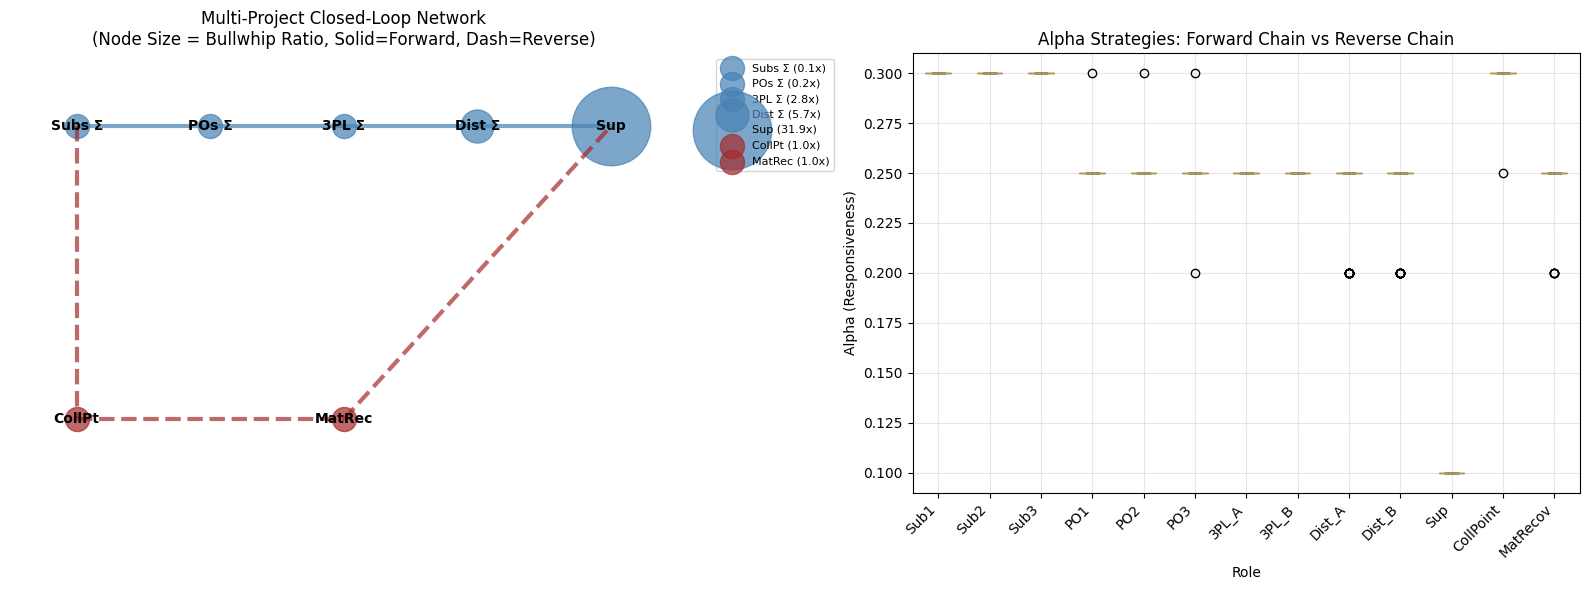

/tmp/ipython-input-1560664389.py:309: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([service_levels_by_period[p] for p in periods], labels=periods)
/tmp/ipython-input-1560664389.py:324: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([alpha_levels_by_period[p] for p in periods if alpha_levels_by_period[p]],


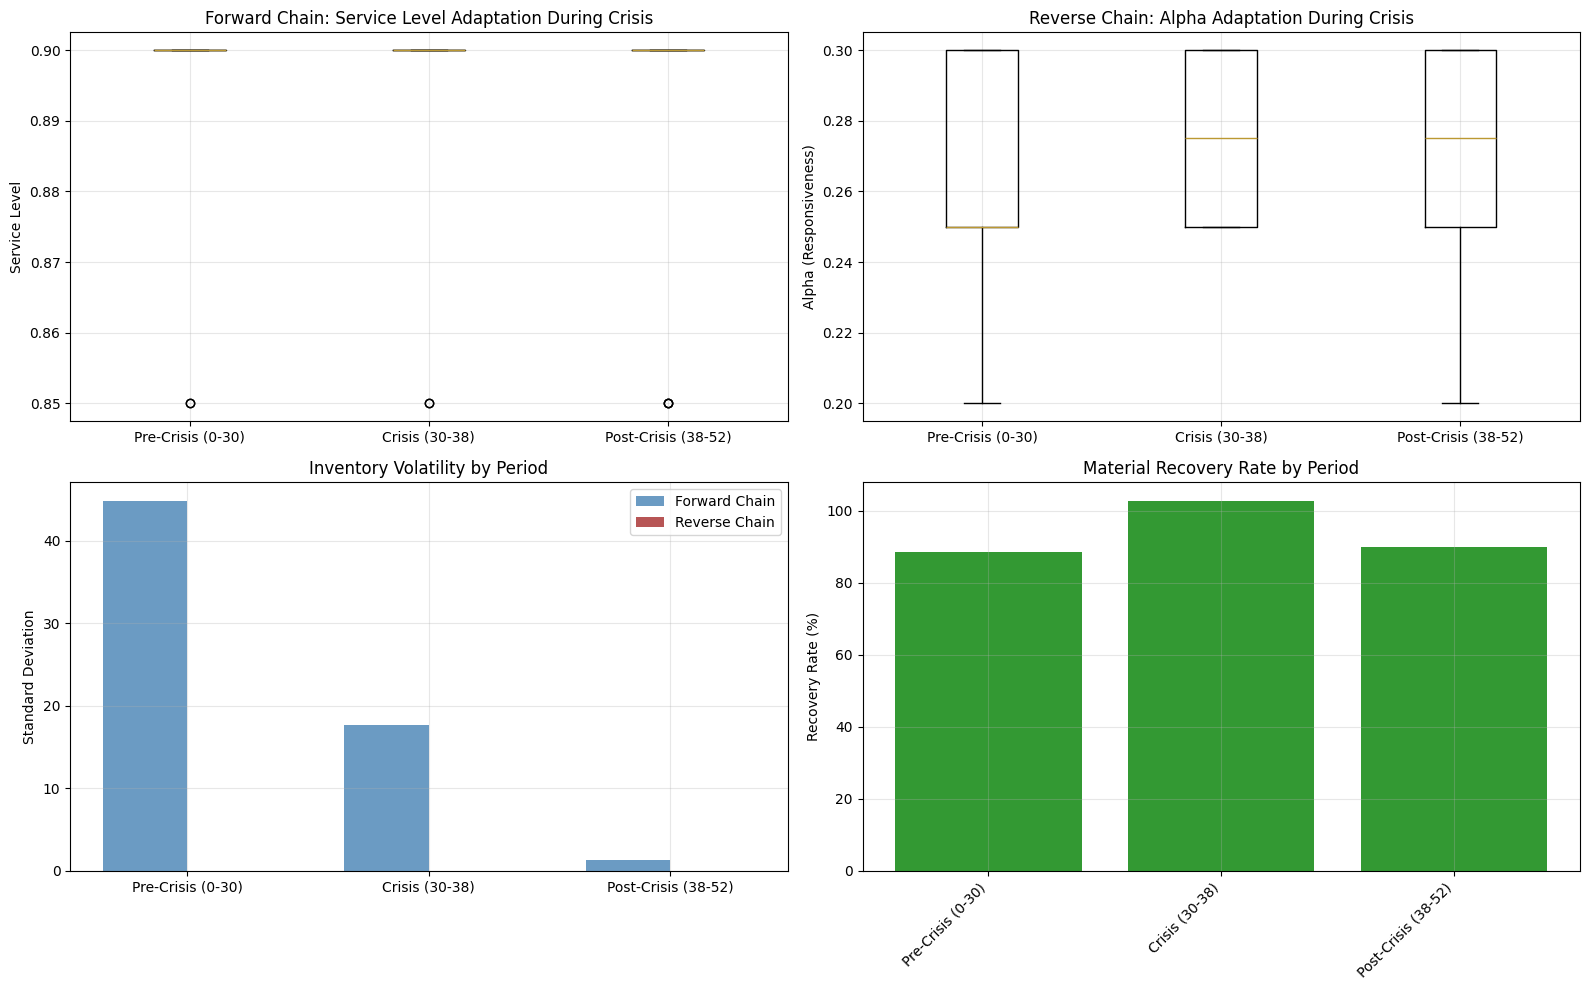

In [ ]:
# ===== Comprehensive Visualizations for Construction Supply Chain Research (multi-project closed-loop) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --- helpers / role groups from run objects ---
SUBS   = [k for k in hist_roles["orders_out"].keys() if k.startswith("Sub")]
POS    = [k for k in hist_roles["orders_out"].keys() if k.startswith("PO")]
THREEP = ["3PL_A","3PL_B"]
DISTS  = ["Dist_A","Dist_B"]
SUPS   = ["Sup"]
COLLPT = [k for k in hist_roles["orders_out"].keys() if k.startswith("CollPoint")]
MATREC = [k for k in hist_roles["orders_out"].keys() if k.startswith("MatRecov")]

def _sum_hist(metric, keys):
    acc = np.zeros(horizonWeeks, dtype=float)
    for k in keys:
        acc += np.asarray(hist_roles[metric].get(k, np.zeros(horizonWeeks)), dtype=float)
    return acc

# Total customer demand and waste across projects
d_total = np.zeros(horizonWeeks, dtype=float)
w_total = np.zeros(horizonWeeks, dtype=float)
for s in SUBS:
    d_total += np.asarray(customerDemand_by_sub[s], dtype=float)
    w_total += np.asarray(projectWaste_by_sub[s], dtype=float)

# Set style for publication-quality plots
plt.style.use('default')
sns.set_palette("husl")

# 1) BULLWHIP CASCADE ANALYSIS (grouped by network position) - EXTENDED FOR CLOSED-LOOP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Forward chain roles
forward_roles_grouped = {
    "Subs Σ":  SUBS,
    "POs Σ":   POS,
    "3PL Σ":   THREEP,
    "Dist Σ":  DISTS,
    "Sup":     SUPS,
}

# Reverse chain roles
reverse_roles_grouped = {
    "CollPt":  COLLPT,
    "MatRec":  MATREC,
}

# Forward chain bullwhip (use df_kpi_forward)
bw_vals_forward, std_vals_forward = [], []
for lbl, members in forward_roles_grouped.items():
    df_sub = df_kpi_forward[df_kpi_forward["role"].isin(members)]
    bw_vals_forward.append(float(df_sub["bullwhip_ratio_var"].mean()))
    std_vals_forward.append(float(df_sub["amplification_std"].mean()))

network_distances_forward = list(range(len(forward_roles_grouped)))
forward_labels = list(forward_roles_grouped.keys())

ax1.plot(network_distances_forward, bw_vals_forward, 'o-', linewidth=3, markersize=8, color='steelblue', label='Forward Chain')
ax1.set_xlabel('Network Distance from Demand Source (Subs)')
ax1.set_ylabel('Bullwhip Ratio (Variance Amplification)')
ax1.set_title('Forward Chain: Bullwhip Amplification by Network Position')
ax1.set_xticks(network_distances_forward)
ax1.set_xticklabels(forward_labels, rotation=0)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Amplification')
ax1.legend()

# Reverse chain bullwhip (use df_kpi_reverse if available)
if COLLPT or MATREC:
    bw_vals_reverse, std_vals_reverse = [], []
    for lbl, members in reverse_roles_grouped.items():
        if 'df_kpi_reverse' in globals():
            df_sub = df_kpi_reverse[df_kpi_reverse["role"].isin(members)]
            if not df_sub.empty:
                bw_vals_reverse.append(float(df_sub["bullwhip_ratio_var"].mean()))
                std_vals_reverse.append(float(df_sub["amplification_std"].mean()))

    if bw_vals_reverse:
        network_distances_reverse = list(range(len(bw_vals_reverse)))
        reverse_labels = list(reverse_roles_grouped.keys())[:len(bw_vals_reverse)]

        ax2.plot(network_distances_reverse, bw_vals_reverse, 'o-', linewidth=3, markersize=8, color='brown', label='Reverse Chain')
        ax2.set_xlabel('Network Distance from Waste Source (Subs)')
        ax2.set_ylabel('Bullwhip Ratio (Variance Amplification)')
        ax2.set_title('Reverse Chain: Waste Processing Amplification')
        ax2.set_xticks(network_distances_reverse)
        ax2.set_xticklabels(reverse_labels, rotation=0)
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Amplification')
        ax2.legend()

plt.tight_layout()
plt.show()

# 2) COEFFICIENT CHOICE HEATMAP BY ROLE (works on all roles including closed-loop)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

alpha_pivot = alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int)
sns.heatmap(alpha_pivot, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Alpha Choices by Role (Demand Responsiveness)')
ax1.set_ylabel('Role')

sl_pivot = sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int)
sns.heatmap(sl_pivot, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Service Level Choices by Role (Safety Stock)')
ax2.set_ylabel('')

lot_pivot = lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int)
sns.heatmap(lot_pivot, annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Lot Multiplier Choices by Role (Order Sizing)')
ax3.set_ylabel('Role')

exp_pivot = exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int)
sns.heatmap(exp_pivot, annot=True, fmt='d', cmap='Reds', ax=ax4)
ax4.set_title('Expedite Choices by Role (Rush Orders)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) TIME SERIES DECOMPOSITION WITH DISRUPTION AND CLOSED-LOOP FLOWS
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

t_idx = np.arange(horizonWeeks)
disruption_start = 30
disruption_end   = 38

# Forward chain orders over time
ax1.plot(t_idx, d_total, 'k-', linewidth=3, label='Total Project Demand (Σ Sub1–3)', alpha=0.9)
ax1.plot(t_idx, _sum_hist("orders_out", SUBS),  label='Subs Σ Orders', alpha=0.8, linewidth=2)
ax1.plot(t_idx, _sum_hist("orders_out", POS),   label='POs Σ Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["3PL_A"]), label='3PL_A Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["3PL_B"]), label='3PL_B Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["Dist_A"]), label='Dist_A Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["Dist_B"]), label='Dist_B Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", SUPS),  label='Sup Orders', alpha=0.7)
ax1.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption Period')
ax1.set_title('Forward Chain: Orders Over Time with Disruption')
ax1.set_xlabel('Time (weeks)'); ax1.set_ylabel('Units')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax1.grid(True, alpha=0.3)

# Reverse chain flows over time
ax2.plot(t_idx, w_total, 'brown', linewidth=3, label='Total Waste Generated (Σ Sub1–3)', alpha=0.9)
if COLLPT:
    ax2.plot(t_idx, _sum_hist("orders_out", COLLPT), label='Waste Processed', alpha=0.8, linewidth=2)
if MATREC:
    ax2.plot(t_idx, _sum_hist("orders_out", MATREC), label='Materials Recovered', alpha=0.8, linewidth=2)
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption Period')
ax2.set_title('Reverse Chain: Waste Processing & Recovery')
ax2.set_xlabel('Time (weeks)'); ax2.set_ylabel('Units')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Inventory levels over time (forward chain)
ax3.plot(t_idx, _sum_hist("on_hand", POS), label='POs Σ Inv', alpha=0.7, linewidth=2)
ax3.plot(t_idx, hist_roles["on_hand"]["3PL_A"], label='3PL_A Inv', alpha=0.7)
ax3.plot(t_idx, hist_roles["on_hand"]["3PL_B"], label='3PL_B Inv', alpha=0.7)
ax3.plot(t_idx, hist_roles["on_hand"]["Dist_A"], label='Dist_A Inv', alpha=0.7)
ax3.plot(t_idx, hist_roles["on_hand"]["Dist_B"], label='Dist_B Inv', alpha=0.7)
ax3.plot(t_idx, hist_roles["on_hand"]["Sup"],   label='Sup Inv', alpha=0.7, linewidth=2)
ax3.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax3.set_title('Forward Chain: Inventory Levels Over Time')
ax3.set_xlabel('Time (weeks)'); ax3.set_ylabel('Units')
ax3.legend(); ax3.grid(True, alpha=0.3)

# Closed-loop inventory levels
if COLLPT or MATREC:
    if COLLPT:
        ax4.plot(t_idx, _sum_hist("on_hand", COLLPT), label='CollPoint Inventory', alpha=0.8, linewidth=2, color='brown')
    if MATREC:
        ax4.plot(t_idx, _sum_hist("on_hand", MATREC), label='MatRecov Inventory', alpha=0.8, linewidth=2, color='orange')
    ax4.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
    ax4.set_title('Reverse Chain: Processing Inventory Levels')
    ax4.set_xlabel('Time (weeks)'); ax4.set_ylabel('Units')
    ax4.legend(); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4) CLOSED-LOOP EFFICIENCY ANALYSIS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Efficiency metrics over time
if "waste_in" in hist_roles and SUBS:
    waste_generated_ts = _sum_hist("waste_in", SUBS)

    if COLLPT:
        waste_collected_ts = _sum_hist("orders_out", COLLPT)
        collection_efficiency_ts = np.divide(waste_collected_ts, waste_generated_ts,
                                           out=np.zeros_like(waste_collected_ts),
                                           where=waste_generated_ts!=0) * 100
        ax1.plot(t_idx, collection_efficiency_ts, label='Collection Efficiency (%)', linewidth=2, alpha=0.8)

    if MATREC:
        materials_recovered_ts = _sum_hist("orders_out", MATREC)
        if COLLPT:
            recovery_efficiency_ts = np.divide(materials_recovered_ts, waste_collected_ts,
                                             out=np.zeros_like(materials_recovered_ts),
                                             where=waste_collected_ts!=0) * 100
            ax1.plot(t_idx, recovery_efficiency_ts, label='Recovery Efficiency (%)', linewidth=2, alpha=0.8)

    ax1.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
    ax1.set_title('Closed-Loop Efficiency Over Time')
    ax1.set_xlabel('Week'); ax1.set_ylabel('Efficiency (%)')
    ax1.legend(); ax1.grid(True, alpha=0.3)

# Material flow sankey-style visualization (simplified as stacked area)
if COLLPT and MATREC:
    # Stack the flows to show material transformation
    ax2.fill_between(t_idx, 0, waste_generated_ts, alpha=0.6, label='Waste Generated', color='brown')
    ax2.fill_between(t_idx, 0, waste_collected_ts, alpha=0.7, label='Waste Collected', color='orange')
    ax2.fill_between(t_idx, 0, materials_recovered_ts, alpha=0.8, label='Materials Recovered', color='green')

    ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
    ax2.set_title('Material Flow Transformation (Cumulative View)')
    ax2.set_xlabel('Week'); ax2.set_ylabel('Units')
    ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) NETWORK STRUCTURE VISUALIZATION (extended for closed-loop)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Forward + reverse chain network
positions = {
    "Subs Σ": (0, 2), "POs Σ": (1, 2), "3PL Σ": (2, 2), "Dist Σ": (3, 2), "Sup": (4, 2),
    "CollPt": (0, 0), "MatRec": (2, 0)
}

# Combine bullwhip values from both chains
all_bullwhip = dict(zip(forward_labels, bw_vals_forward))
if COLLPT:
    all_bullwhip["CollPt"] = 1.0  # Default if no reverse bullwhip calculated
if MATREC:
    all_bullwhip["MatRec"] = 1.0

for role, (x, y) in positions.items():
    if role in all_bullwhip:
        size = max(300, all_bullwhip[role] * 100)
        color = 'steelblue' if y > 1 else 'brown'  # Blue for forward, brown for reverse
        ax1.scatter(x, y, s=size, alpha=0.7, color=color, label=f'{role} ({all_bullwhip[role]:.1f}x)')
        ax1.annotate(role, (x, y), ha='center', va='center', fontweight='bold')

# Forward chain connections
forward_connections = [("Subs Σ", "POs Σ"), ("POs Σ", "3PL Σ"), ("3PL Σ", "Dist Σ"), ("Dist Σ", "Sup")]
for start, end in forward_connections:
    if start in positions and end in positions:
        x1, y1 = positions[start]; x2, y2 = positions[end]
        ax1.plot([x1, x2], [y1, y2], 'steelblue', alpha=0.7, linewidth=3)

# Reverse chain connections
reverse_connections = [("Subs Σ", "CollPt"), ("CollPt", "MatRec"), ("MatRec", "Sup")]
for start, end in reverse_connections:
    if start in positions and end in positions:
        x1, y1 = positions[start]; x2, y2 = positions[end]
        ax1.plot([x1, x2], [y1, y2], 'brown', alpha=0.7, linewidth=3, linestyle='--')

ax1.set_title('Multi-Project Closed-Loop Network\n(Node Size = Bullwhip Ratio, Solid=Forward, Dash=Reverse)')
ax1.set_xlim(-0.5, 4.5); ax1.set_ylim(-0.5, 2.5)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8); ax1.axis('off')

# Alpha strategies comparison: Forward vs Reverse chain
alpha_data_forward = {}
alpha_data_reverse = {}

for r in SUBS + POS + THREEP + DISTS + SUPS:
    if r in coeff_logs and coeff_logs[r]:
        alpha_data_forward[r] = [c["alpha"] for c in coeff_logs[r]]

for r in COLLPT + MATREC:
    if r in coeff_logs and coeff_logs[r]:
        alpha_data_reverse[r] = [c["alpha"] for c in coeff_logs[r]]

# Boxplot comparison
all_alpha_data = {**alpha_data_forward, **alpha_data_reverse}
labels = list(all_alpha_data.keys())
colors = ['steelblue' if any(r in label for r in SUBS + POS + THREEP + DISTS + SUPS) else 'brown' for label in labels]

bp = ax2.boxplot([all_alpha_data[r] for r in labels], labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('Alpha Strategies: Forward Chain vs Reverse Chain')
ax2.set_ylabel('Alpha (Responsiveness)'); ax2.set_xlabel('Role')
ax2.grid(True, alpha=0.3); plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 6) DISRUPTION IMPACT ANALYSIS (before, during, after)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

periods = ["Pre-Crisis (0-30)", "Crisis (30-38)", "Post-Crisis (38-52)"]
period_ranges = [(0, 30), (30, 38), (38, 52)]

# Forward chain service levels during periods
service_levels_by_period = {period: [] for period in periods}
for i, (start, end) in enumerate(period_ranges):
    period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
    period_data_forward = period_data[period_data["role"].isin(SUBS + POS + THREEP + DISTS + SUPS)]
    if not period_data_forward.empty:
        service_levels_by_period[periods[i]] = period_data_forward["service_level"].tolist()

ax1.boxplot([service_levels_by_period[p] for p in periods], labels=periods)
ax1.set_title('Forward Chain: Service Level Adaptation During Crisis')
ax1.set_ylabel('Service Level')
ax1.grid(True, alpha=0.3)

# Reverse chain alpha evolution during periods (if available)
if COLLPT or MATREC:
    alpha_levels_by_period = {period: [] for period in periods}
    for i, (start, end) in enumerate(period_ranges):
        period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
        period_data_reverse = period_data[period_data["role"].isin(COLLPT + MATREC)]
        if not period_data_reverse.empty:
            alpha_levels_by_period[periods[i]] = period_data_reverse["alpha"].tolist()

    if any(alpha_levels_by_period.values()):
        ax2.boxplot([alpha_levels_by_period[p] for p in periods if alpha_levels_by_period[p]],
                   labels=[p for p in periods if alpha_levels_by_period[p]])
        ax2.set_title('Reverse Chain: Alpha Adaptation During Crisis')
        ax2.set_ylabel('Alpha (Responsiveness)')
        ax2.grid(True, alpha=0.3)

# Inventory volatility before/during/after crisis
inventory_volatility = {}
for role_group, roles in [("Forward", THREEP + DISTS + SUPS), ("Reverse", COLLPT + MATREC)]:
    volatilities = []
    for start, end in period_ranges:
        period_inventory = _sum_hist("on_hand", roles)[start:end]
        volatilities.append(np.std(period_inventory) if len(period_inventory) > 1 else 0)
    inventory_volatility[role_group] = volatilities

x = np.arange(len(periods))
width = 0.35
ax3.bar(x - width/2, inventory_volatility.get("Forward", [0]*3), width, label='Forward Chain', alpha=0.8, color='steelblue')
ax3.bar(x + width/2, inventory_volatility.get("Reverse", [0]*3), width, label='Reverse Chain', alpha=0.8, color='brown')
ax3.set_title('Inventory Volatility by Period')
ax3.set_ylabel('Standard Deviation')
ax3.set_xticks(x)
ax3.set_xticklabels(periods)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Recovery rate stability during crisis
if MATREC and COLLPT:
    recovery_rates = []
    for start, end in period_ranges:
        waste_in_period = _sum_hist("orders_out", COLLPT)[start:end].sum()
        materials_out_period = _sum_hist("orders_out", MATREC)[start:end].sum()
        rate = (materials_out_period / waste_in_period * 100) if waste_in_period > 0 else 0
        recovery_rates.append(rate)

    ax4.bar(periods, recovery_rates, alpha=0.8, color='green')
    ax4.set_title('Material Recovery Rate by Period')
    ax4.set_ylabel('Recovery Rate (%)')
    ax4.grid(True, alpha=0.3)
    plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()